# Análisis Exploratorio de Datos

## Librerías

In [55]:
import pandas as pd
import numpy as np
import missingno as msno
import scikit_posthocs as sp
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

from scipy.stats import kruskal
from collections import defaultdict
from scipy.stats import chi2_contingency

In [56]:
pd.options.display.float_format = '{:,.2f}'.format

## Lectura

In [57]:
df = pd.read_excel('registros.xlsx')

In [58]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3471 entries, 0 to 3470
Data columns (total 40 columns):
 #   Column                                               Non-Null Count  Dtype  
---  ------                                               --------------  -----  
 0   codigo                                               3471 non-null   str    
 1   edad                                                 3470 non-null   float64
 2   dias_abstinencia                                     3471 non-null   int64  
 3   nombre                                               3471 non-null   str    
 4   volumen_ml                                           3467 non-null   float64
 5   ph                                                   2958 non-null   float64
 6   mucolisis                                            3437 non-null   str    
 7   viscosidad                                           3421 non-null   str    
 8   color                                                3412 non-null   str    
 9

**Resumen General**

Este DataFrame contiene 3,471 registros de análisis de semen (espermiogramas) con 40 columnas, lo que representa una base de datos clínica de fertilidad masculina.


**Estructura de los Datos**

- **1. Variables Identificativas**
    - `codigo`: Identificador único del paciente (string)
    - `nombre`: Nombre del paciente (string)
    - `identificacion`: Otro tipo de identificación (object, 3 valores nulos)
    - `año`: Año del estudio (int64)

- **2. Variables Demográficas**
    - `edad`: Edad del paciente (float64, 1 valor nulo)
    - `dias_abstinencia`: Días de abstinencia sexual previa (int64, completo)

- **3. Variables del Seminograma (Principales)**

    - **Características Físicas:**
        - `volumen_ml`: Volumen de la muestra en ml (float64, 4 nulos)
        - `ph`: pH de la muestra (float64, 513 nulos)
        - `mucolisis`: Característica de la mucosidad (string, 34 nulos)
        - `viscosidad`: Grado de viscosidad (string, 50 nulos)
        - `color`: Color de la muestra (string, 59 nulos)
        - `olor`: Olor de la muestra (string, 643 nulos)

    - **Recuento Celular:**
        - `celulas_redondas`: Células redondas presentes (object, 261 nulos)
        - `leucocitos`: Presencia de leucocitos (object, 1,508 nulos)
        - `espermatozoides_por_eyaculado`: Número total (float64, 3 nulos)
        - `concentracion_por_ml`: Concentración en millones/ml (float64, 3 nulos)

    - **Viabilidad y Motilidad:**
        - `test_eosina_pct`: Porcentaje de espermatozoides viables (float64, 593 nulos)
        - `motilidad_progresiva_pct`: % con movimiento progresivo (float64, 5 nulos)
        - `motilidad_no_progresiva_pct`: % con movimiento no progresivo (float64, 4 nulos)
        - `inmovil_pct`: % de espermatozoides inmóviles (float64, 4 nulos)
        - `motilidad_total_pct`: % de motilidad total (float64, 4 nulos)

    - **Morfología:**
        - `espermatozoides_normales_pct`: % normales (float64, 627 nulos)
        - `espermatozoides_anormales_pct`: % anormales (float64, 628 nulos)
        - `alt_cabeza_pct`: % alteraciones de cabeza (float64, 634 nulos)
        - `alt_cola_pct`: % alteraciones de cola (float64, 642 nulos)
        - `alt_pieza_intermedia_pct`: % alteraciones de pieza intermedia (float64, 633 nulos)
        - `indice_teratozoospermia`: Índice de teratozoospermia (float64, 635 nulos)

- **4. Variables Derivadas/Verificación**
    - `concentracion_total/volumen = concentracion_volumen`: Verificación de cálculo (string, 176 nulos)
    - `motilidad_suma_bien`: Verificación de suma de motilidades (string, 203 nulos)
    - `motilidad_inmovil_100`: Verificación de consistencia (string, completo)
    - `espermatozoides_normales_anormales=100`: Verificación de suma normales+anormales (string, completo)

- **5. Observaciones**
    - `comentarios`: Notas clínicas (string, 117 nulos)
    - `tipo_comentario`: Categoría del comentario (string, completo)
    - `otras_celulas`: Otras células presentes (string, 3,367 nulos)
    - `trazas_gel`: Presencia de trazas de gel (string, completo)
    - `examen_hora`: Presencia de bacterias (string, 962 nulos)

- **6. Registros Adicionales**
    - `rem1`, `rem2`, `rem3`: Campos de observación/revisión (object)


**Fortalezas**
- Buen tamaño muestral (3,471 registros)  
- Variables clínicas completas en su mayoría  
- Incluye verificaciones de consistencia interna  
- Cubre todos los parámetros clave de un espermiograma estándar (OMS)

## Análisis de Completitud de Datos en Registros

Con el objetivo de evaluar la calidad e integridad de la base de datos de seminogramas, se procede a calcular un indicador de completitud para cada registro. Este indicador cuantifica el número total de campos no nulos presentes en cada fila del DataFrame, permitiendo identificar aquellos pacientes con información incompleta que podrían requerir un análisis más detallado o ser excluidos de estudios posteriores.

In [59]:
df["completitud"] = df.notna().sum(axis=1)
df["completitud"].describe()

count   3,471.00
mean       33.45
std         4.07
min        15.00
25%        33.00
50%        35.00
75%        36.00
max        39.00
Name: completitud, dtype: float64

**Resumen General**

Los resultados muestran que, en promedio, cada registro tiene 34.45 campos completos de un total de 40 columnas, lo que representa un 86.1% de completitud general. Esto indica una buena calidad de datos en términos de integridad.

**Análisis Detallado por Estadísticos**

- **1. Medidas de Tendencia Central**
    - **Media = 34.45**: Promedio de campos completos por registro
    - **Mediana (50%) = 36.00**: La mitad de los registros tienen 36 o más campos completos
    - **Media vs Mediana**: La media es ligeramente menor que la mediana (34.45 vs 36.00), lo que sugiere que hay algunos registros con valores extremadamente bajos (sesgo negativo)

- **2. Distribución Percentilar**
    - **25% (Q1) = 34.00**: El 25% de los registros tienen ≤ 34 campos completos (85% de completitud)
    - **75% (Q3) = 37.00**: El 75% de los registros tienen ≤ 37 campos completos (92.5% de completitud)
    - **Rango intercuartílico (IQR) = 3**: La mayoría de los registros (50% central) tienen entre 34 y 37 campos completos, indicando alta consistencia

- **3. Valores Extremos**
    - **Mínimo = 16.00**: El registro más incompleto solo tiene 16 campos (40% de completitud)
    - **Máximo = 40.00**: Al menos un registro está completamente lleno (100% de completitud)
    - **Rango = 24**: Gran variabilidad entre el peor y el mejor registro

- **4. Dispersión**
    - **Desviación estándar = 4.07**: Variabilidad moderada alrededor de la media
    - **Coeficiente de variación (CV) = 4.07/34.45 = 11.8%**: Dispersión relativamente baja, indicando consistencia en los datos


**Fortalezas**

- **Excelente calidad general**: 86% de completitud promedio es alto para datos clínicos
- **Datos mayoritariamente completos**: El percentil 75 muestra que 3/4 de los registros tienen ≥ 37 campos (92.5%)
- **Baja variabilidad**: La mayoría de los registros son consistentes entre sí

## Visualización de Patrones de Datos Faltantes

Para identificar visualmente la distribución y los patrones de valores ausentes en el DataFrame, se emplea un gráfico de matriz de nulos (missingno matrix). Esta visualización permite detectar:
- Columnas con mayor proporción de datos faltantes.
- Patrones sistemáticos de valores ausentes.
- Posibles relaciones entre variables incompletas.
- Registros que concentran múltiples valores faltantes.

<Figure size 1600x800 with 0 Axes>

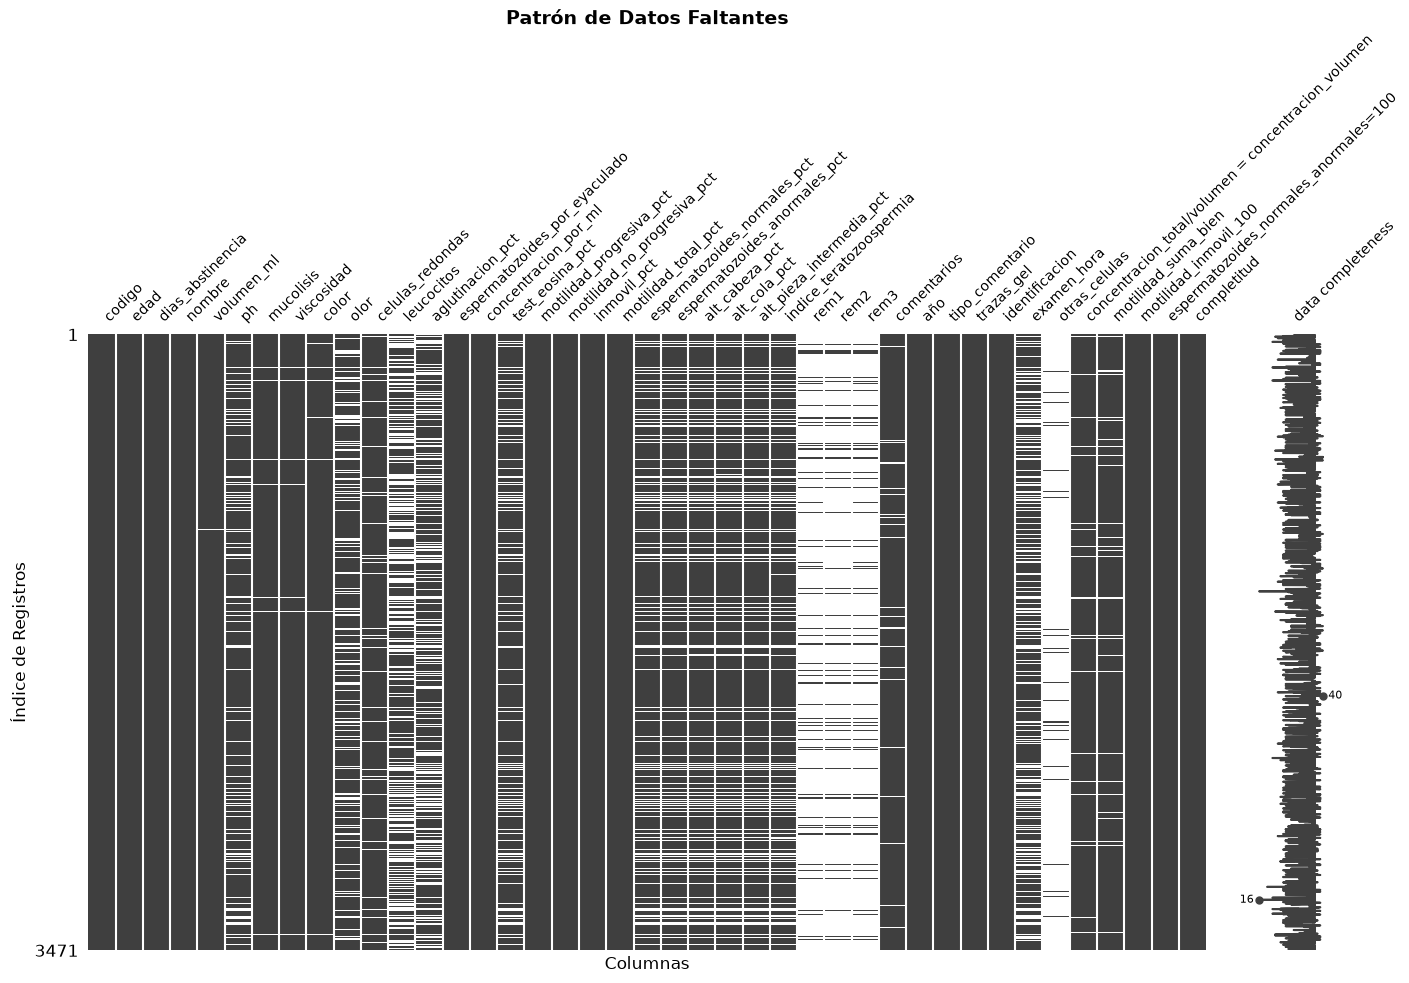

In [60]:
plt.figure(figsize=(16, 8))
msno.matrix(
    df,
    figsize=(16, 8),
    fontsize=10,
    sparkline=True,  
    labels=True      
)
plt.title('Patrón de Datos Faltantes', fontsize=14, fontweight='bold')
plt.ylabel('Índice de Registros', fontsize=12)
plt.xlabel('Columnas', fontsize=12)
plt.tight_layout()
plt.show()

## Análisis de Valores Faltantes por Variable

Para complementar el análisis visual de datos ausentes, se elabora un resumen estadístico que cuantifica la cantidad y porcentaje de valores faltantes para cada una de las 40 variables del estudio. Este resumen permitirá:
- Identificar las variables con mayor proporción de datos ausentes.
- Establecer umbrales de exclusión para variables con excesivos nulos.
- Evaluar el impacto de los datos faltantes en análisis específicos.

In [61]:
resumen = pd.DataFrame({
    'No Nulos': df.count(),
    'Nulos': df.isnull().sum(),
    '% Faltantes': (df.isnull().sum() / len(df) * 100)
}).sort_values('% Faltantes', ascending=False)

display(resumen)

,No Nulos,Nulos,% Faltantes
otras_celulas,104,3367,97.00
rem2,350,3121,89.92
rem1,387,3084,88.85
rem3,390,3081,88.76
leucocitos,1963,1508,43.45
aglutinacion_pct,2350,1121,32.30
examen_hora,2509,962,27.72
olor,2828,643,18.52
alt_cola_pct,2829,642,18.50
indice_teratozoospermia,2836,635,18.29


**Resumen General**

El análisis de completitud por variable revela una base de datos con calidad heterogénea, donde encontramos desde variables perfectamente completas (0% nulos) hasta variables prácticamente vacías (97% nulos). Se identifican 4 grupos claramente diferenciados según el porcentaje de datos faltantes.

**Grupo 1: Variables Críticas (>30% Nulos)**

| Variable | Nulos | % Faltantes |
|----------|-------|-------------|
| `otras_celulas` | 3,367 | 97.00% |
| `rem2` | 3,121 | 89.92% |
| `rem1` | 3,084 | 88.85%** |
| `rem3` | 3,081 | 88.76% |
| `leucocitos` | 1,508 | 43.45% |
| `aglutinacion_pct` | 1,121 | **32.30%** |
| `examen_hora` | 962 | **27.72%** |

**Grupo 2: Variables con Nulos Moderados (10-30%)**

| Variable | Nulos | % Faltantes |
|----------|-------|-------------|
| `olor` | 643 | 18.52% |
| `alt_cola_pct` | 642 | 18.50% |
| `indice_teratozoospermia` | 635 | 18.29% |
| `alt_cabeza_pct` | 634 | 18.27% |
| `alt_pieza_intermedia_pct` | 633 | 18.24% |
| `espermatozoides_anormales_pct` | 628 | 18.09% |
| `espermatozoides_normales_pct` | 627 | 18.06% |
| `test_eosina_pct` | 593 | 17.08% |
| `ph` | 513 | 14.78% |

**Patrón Identificado**: Las variables de morfología (alt_cabeza, alt_cola, alt_pieza, índice, normales/anormales) tienen ~18% de nulos de manera consistente. Esto sugiere que los datos faltantes no son aleatorios, probablemente corresponden a muestras donde no se realizó el análisis morfológico completo.

**Grupo 3: Variables con Bajo Nivel de Nulos (1-10%)**

| Variable | Nulos | % Faltantes |
|----------|-------|-------------|
| `celulas_redondas` | 261 | 7.52% |
| `motilidad_suma_bien` | 203 | 5.85% |
| `concentracion_total/volumen` | 176 | 5.07% |
| `comentarios` | 117 | 3.37% |
| `color` | 59 | 1.70% |
| `viscosidad` | 50 | 1.44% |
| `mucolisis` | 34 | 0.98% |

**Grupo 4: Variables Prácticamente Completas (<1% Nulos)**

| Variable | Nulos | % Faltantes |
|----------|-------|-------------|
| `motilidad_progresiva_pct` | 5 | 0.14% |
| `volumen_ml` | 4 | 0.12% |
| `motilidad_total_pct` | 4 | 0.12% |
| `motilidad_no_progresiva_pct` | 4 | 0.12% |
| `inmovil_pct` | 4 | 0.12% |
| `espermatozoides_por_eyaculado` | 3 | 0.09% |
| `concentracion_por_ml` | 3 | 0.09% |
| `identificacion` | 3 | 0.09% |
| `edad` | 1 | 0.03% |
| **8 variables** | 0 | 0.00% |

**Variables perfectas (0% nulos)**: `codigo`, `nombre`, `dias_abstinencia`, `año` `tipo_comentario`, `trazas_gel`, `motilidad_inmovil_100`, `espermatozoides_normales_anormales=100` y `completitud` (calculada)

**Patrones y Hallazgos Clave**

1. **Variables de Verificación**
   - `motilidad_inmovil_100` (100% completa) - Buena señal de control de calidad
   - `espermatozoides_normales_anormales=100` (100% completa) - Buena señal
   - `motilidad_suma_bien` (94.15% completa) - Mayoría de registros consistentes

2. **Variables Clínicas Clave**

| Categoría | Variables | Completitud |
|-----------|-----------|-------------|
| **Motilidad** | Todas las de motilidad | 99.86% | 
| **Concentración** | Concentración y total | 99.91% |
| **Volumen** | volumen_ml | 99.88% |
| **Morfología** | Todas las de morfología | ~82% |
| **Viabilidad** | test_eosina_pct | 82.92% |
| **Leucocitos** | leucocitos | 56.55% |

---

**Exclusión de Variables**

Las variables `color`, `olor`, `leucocitos`, `otras_celulas` y `REM` (rem1, rem2, rem3) fueron conservadas en la base de datos original, sin embargo, no se incluyeron en el análisis exploratorio posterior debido a las siguientes razones:

- **1. Variables descriptivas cualitativas: Color y Olor**

   - **Naturaleza subjetiva**: Son variables cualitativas con escaso valor estadístico para modelos cuantitativos
   - **Bajo poder explicativo**: Aportan información clínica orientativa pero no significativa para análisis correlacionales
   - **Limitaciones metodológicas**: Su evaluación depende de la percepción del técnico y condiciones de procesamiento

- **2. Variables REM (rem1, rem2, rem3)**

   - **Datos insuficientes**: Presentan entre 88.8% y 89.9% de valores faltantes
   - **Campos obsoletos**: Probablemente corresponden a campos administrativos en desuso del sistema de registro
   - **No representativos**: Los pocos registros con datos no son representativos de la muestra total

- **3. Variable "otras_celulas"**

   - **Datos prácticamente inexistentes**: 97% de valores faltantes (solo 104 registros completos)
   - **Registro esporádico**: Solo se anotaba ante hallazgos excepcionales, introduciendo sesgo de notificación

- **4. Variable "leucocitos"**

   - **Alto porcentaje de faltantes**: **43.45%** de datos ausentes (1,508 casos sin registro)
   - **Conversación con experta**: La doctora Yeira manifestó que esta variable no era de importancia en el estudio

**Conclusión**

La exclusión de estas variables se basa en criterios de calidad de datos (alto porcentaje de nulos), relevancia clínica (bajo valor predictivo) y robustez metodológica (evitar sesgos y pérdida de potencia estadística). El conjunto final de variables seleccionadas garantiza un análisis confiable con un tamaño muestral adecuado para cada variable incluida.

In [62]:
df = df.drop(columns=['olor','color','leucocitos','rem1','rem2','rem3', 'otras_celulas'])

## **Grupos diagnosticos y definición**	
* **Azoospermia**	- Absence or complete lack of spermatozoa in the ejaculate
* **Oligozoospermia** -	Sperm count less than 15 million per ml
* **Teratozoospermia**	- having less than 4% of sperm with normal morphology
* **Asthenoteratozoospermia**	- having less than 42% of all motile sperm and less than 4% of sperm with normal morphology
* **Oligoasthenoteratozoospermia** (OAT)	- less than 15 million sperm/mL, less than 42% total motility, and less than 4% of normal morphology
* **Oligoasthenozoospermia**	- Having less than 4% normal morphology of sperm and less than 15 million sperm per ml
* **Oligoteratozoospermia**	- Having less than 4% normal morphology and less than 15 million sperm per ml
* **Normozoospermia**	- having semen parameters (≥15 million sperm/mL, ≥40% overall motility, and ≥4% normal morphology)

In [11]:
condiciones = [

    # Azoospermia
    df['concentracion_por_ml'] == 0,

    # Oligoasthenoteratozoospermia (OAT)
    (
        (df['concentracion_por_ml'] < 15000000) &
        (df['motilidad_total_pct'] < 42) &
        (df['espermatozoides_normales_pct'] < 4)
    ),

    # Asthenoteratozoospermia
    (
        (df['motilidad_total_pct'] < 42) &
        (df['espermatozoides_normales_pct'] < 4)
    ),

    # Oligoasthenozoospermia
    (
        (df['concentracion_por_ml'] < 15000000) &
        (df['motilidad_total_pct'] < 42)
    ),

    # Oligoteratozoospermia
    (
        (df['concentracion_por_ml'] < 15000000) &
        (df['espermatozoides_normales_pct'] < 4)
    ),

    # Oligozoospermia
    (
        df['concentracion_por_ml'] < 15000000
    ),

    # Teratozoospermia
    (
        df['espermatozoides_normales_pct'] < 4
    ),

    # Normozoospermia
    (
        (df['concentracion_por_ml'] >= 15000000) &
        (df['motilidad_total_pct'] >= 40) &
        (df['espermatozoides_normales_pct'] >= 4)
    )
]

diagnosticos = [
    'Azoospermia',
    'Oligoasthenoteratozoospermia',
    'Asthenoteratozoospermia',
    'Oligoasthenozoospermia',
    'Oligoteratozoospermia',
    'Oligozoospermia',
    'Teratozoospermia',
    'Normozoospermia'
]

df['diagnostico'] = np.select(
    condiciones,
    diagnosticos,
    default='Otros'
)

* **Oligo**: concentración espermática <15 millones/mL.
* **Terato**: <4 % de espermatozoides con morfología normal.
* **Astheno**: motilidad total <42 %.

In [12]:
df['diagnostico'].value_counts()

diagnostico
Normozoospermia                 906
Teratozoospermia                817
Otros                           550
Oligoasthenoteratozoospermia    437
Asthenoteratozoospermia         243
Oligoteratozoospermia           174
Azoospermia                     172
Oligoasthenozoospermia          103
Oligozoospermia                  69
Name: count, dtype: int64

### **Categorías por año**


Distribución porcentual del diagnóstico por año


diagnostico,Asthenoteratozoospermia,Azoospermia,Normozoospermia,Oligoasthenoteratozoospermia,Oligoasthenozoospermia,Oligoteratozoospermia,Oligozoospermia,Otros,Teratozoospermia
año,,,,,,,,,
17,6.27,5.72,22.62,15.80,1.63,6.54,1.36,1.63,38.42
18,7.90,4.06,29.12,13.77,2.48,6.09,1.81,10.16,24.60
19,5.10,7.10,31.04,13.30,3.55,4.43,2.44,11.31,21.73
20,5.48,6.13,29.68,12.58,2.90,6.77,2.58,12.90,20.97
21,9.26,3.97,30.42,12.70,2.12,2.91,1.32,18.78,18.52
22,5.95,5.68,28.38,10.54,4.32,4.05,2.43,18.65,20.00
23,5.74,3.83,25.68,10.93,3.28,6.28,2.73,24.86,16.67
24,5.95,3.57,24.70,12.20,2.68,3.87,1.49,23.81,21.73
25,10.11,4.37,16.39,11.48,3.55,4.37,1.91,21.04,26.78


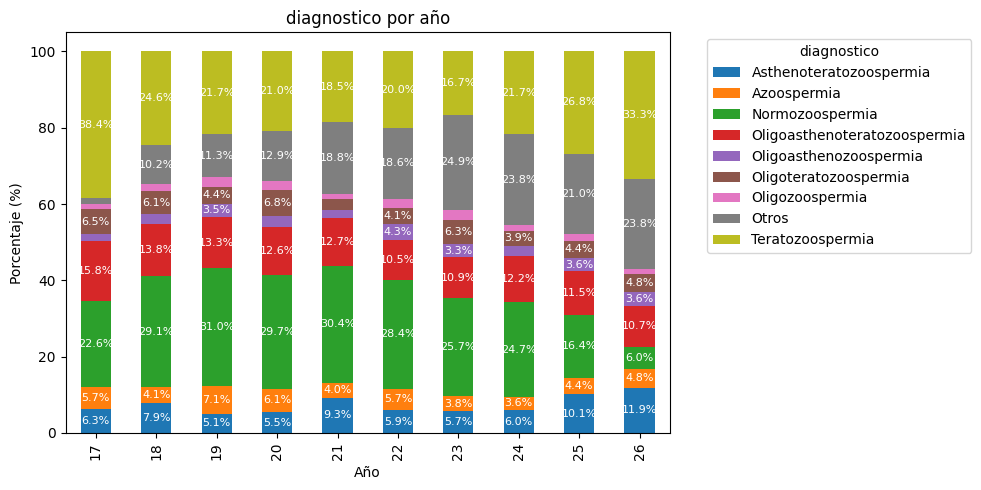

In [13]:
def grafica_proporcion(var):
    tabla = (
        pd.crosstab(
            df['año'],
            df[var],
            normalize='index'
        ) * 100
    )

    print('\nDistribución porcentual del diagnóstico por año')
    display(tabla.round(2))

    ax = tabla.plot(
        kind='bar',
        stacked=True,
        figsize=(10, 5)
    )

    for container in ax.containers:
        labels = [
            f'{bar.get_height():.1f}%'
            if bar.get_height() >= 3 else ''  
            for bar in container
        ]
        ax.bar_label(
            container,
            labels=labels,
            label_type='center',
            fontsize=8,
            color='white'
        )

    plt.ylabel('Porcentaje (%)')
    plt.xlabel('Año')
    plt.title(f'{var} por año')
    plt.legend(title=f'{var}', bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    plt.show()

grafica_proporcion('diagnostico')

Aumento en categoría otros, esto se debe que hay pacientes que no cuentan con la variable de 'espermatozoides_normales_pct', por lo tanto, es imposible clasificarlos en alguna categoría

In [14]:
df[df['diagnostico']=='Otros'][['concentracion_por_ml','motilidad_total_pct','espermatozoides_normales_pct']]

,concentracion_por_ml,motilidad_total_pct,espermatozoides_normales_pct
6,"28,000,000.00",58.00,NaN
10,"40,000,000.00",28.00,NaN
13,"20,500,000.00",6.00,NaN
18,"102,000,000.00",91.00,NaN
29,"98,000,000.00",53.00,NaN
...,...,...,...
3438,"33,000,000.00",56.00,NaN
3439,"15,000,000.00",54.00,NaN
3446,"30,000,000.00",49.00,NaN
3450,"132,000,000.00",80.00,NaN


### **Proporción de NA por año en variable espermatozoides_normales_pct**


Porcentaje de valores faltantes en espermatozoides_normales_pct por año


,Porcentaje NA
año,
17,3.00
18,9.93
19,15.30
20,17.10
21,19.31
22,22.16
23,28.14
24,23.81
25,24.59


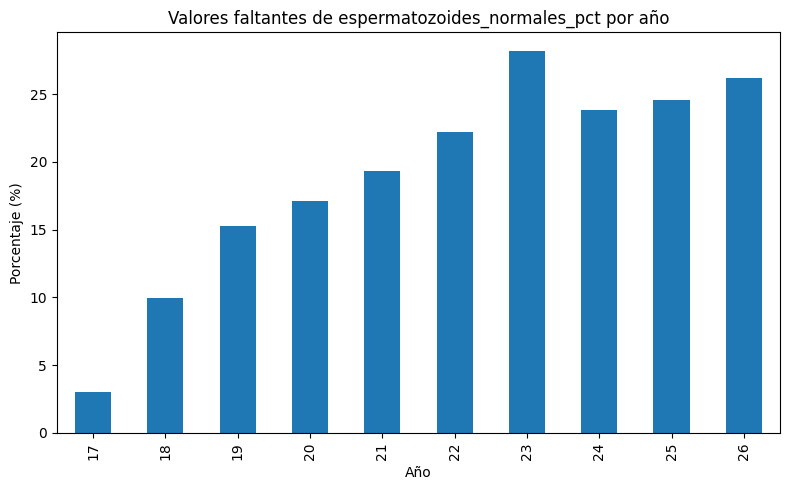

In [15]:
tabla_na = (
    df.groupby('año')['espermatozoides_normales_pct']
      .apply(lambda x: x.isna().mean() * 100)
      .to_frame(name='Porcentaje NA')
)

print('\nPorcentaje de valores faltantes en espermatozoides_normales_pct por año')
display(tabla_na.round(2))

tabla_na.plot(
    kind='bar',
    figsize=(8, 5),
    legend=False
)

plt.ylabel('Porcentaje (%)')
plt.xlabel('Año')
plt.title('Valores faltantes de espermatozoides_normales_pct por año')

plt.tight_layout()
plt.show()

### **Diferencias significativas en grupos diagnosticos**

In [16]:
def chi_proporciones(var):

    tabla = pd.crosstab(df['año'], df[var])

    display(tabla)

    chi2, p, gl, esperados = chi2_contingency(tabla)

    print(f"Chi² = {chi2:.3f}")
    print(f"Grados de libertad = {gl}")
    print(f"p-value = {p:.5f}")

    n = tabla.to_numpy().sum()
    k = min(tabla.shape) - 1

    cramers_v = np.sqrt(chi2 / (n * k))

    print(f"V de Cramér = {cramers_v:.3f}")

chi_proporciones('diagnostico')

diagnostico,Asthenoteratozoospermia,Azoospermia,Normozoospermia,Oligoasthenoteratozoospermia,Oligoasthenozoospermia,Oligoteratozoospermia,Oligozoospermia,Otros,Teratozoospermia
año,,,,,,,,,
17,23,21,83,58,6,24,5,6,141
18,35,18,129,61,11,27,8,45,109
19,23,32,140,60,16,20,11,51,98
20,17,19,92,39,9,21,8,40,65
21,35,15,115,48,8,11,5,71,70
22,22,21,105,39,16,15,9,69,74
23,21,14,94,40,12,23,10,91,61
24,20,12,83,41,9,13,5,80,73
25,37,16,60,42,13,16,7,77,98


Chi² = 259.237
Grados de libertad = 72
p-value = 0.00000
V de Cramér = 0.097


## **Diagnostico solo con concentración**

In [17]:
condiciones = [

    # Azoospermia
    df['concentracion_por_ml'] == 0,

    # Oligozoospermia
    (
        (df['concentracion_por_ml'] < 15000000)
    ),

    # Normozoospermia
    (
        (df['concentracion_por_ml'] >= 15000000) 
    )
]

diagnosticos = [
    'Azoospermia',
    'Oligozoospermia',
    'Normozoospermia',
]

df['diagnostico'] = np.select(
    condiciones,
    diagnosticos,
    default='Otros'
)

### **Categorías por año**


Distribución porcentual del diagnóstico por año


diagnostico,Azoospermia,Normozoospermia,Oligozoospermia,Otros
año,,,,
17,5.72,68.94,25.34,0.00
18,4.06,71.78,24.15,0.00
19,7.10,69.18,23.73,0.00
20,6.13,68.71,24.84,0.32
21,3.97,76.98,19.05,0.00
22,5.68,72.97,21.35,0.00
23,3.83,72.68,23.22,0.27
24,3.57,76.19,20.24,0.00
25,4.37,74.32,21.31,0.00


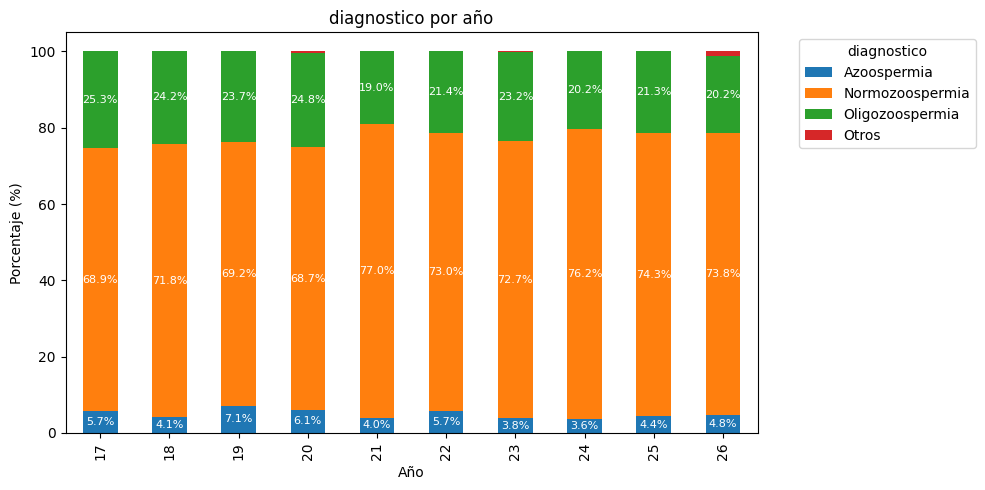

In [18]:
grafica_proporcion('diagnostico')

In [19]:
df[df['diagnostico']=='Otros'][['concentracion_por_ml','motilidad_total_pct','espermatozoides_normales_pct','tipo_comentario']]

,concentracion_por_ml,motilidad_total_pct,espermatozoides_normales_pct,tipo_comentario
1447,NaN,NaN,NaN,congelacion
3112,NaN,56.00,NaN,fragmentacion_adn
3185,NaN,NaN,NaN,fragmentacion_adn


### **Diferencias significativas en las proporciones de grupos diagnosticos por año?**

In [20]:
chi_proporciones('diagnostico')

diagnostico,Azoospermia,Normozoospermia,Oligozoospermia,Otros
año,,,,
17,21,253,93,0
18,18,318,107,0
19,32,312,107,0
20,19,213,77,1
21,15,291,72,0
22,21,270,79,0
23,14,266,85,1
24,12,256,68,0
25,16,272,78,0


Chi² = 37.705
Grados de libertad = 27
p-value = 0.08264
V de Cramér = 0.060


## **Viscosidad por año**


Distribución porcentual del diagnóstico por año


viscosidad,AUMENTADA,LIGERAMENTE AUMENTADA,MUY AUMENTADA,NORMAL
año,,,,
17,33.51,11.72,0.00,54.77
18,30.16,12.47,0.00,57.37
19,32.44,10.51,0.00,57.05
20,24.51,10.78,0.00,64.71
21,24.87,8.02,0.53,66.58
22,17.08,7.71,0.00,75.21
23,21.21,5.51,0.00,73.28
24,22.12,7.58,0.00,70.30
25,25.55,11.26,0.00,63.19


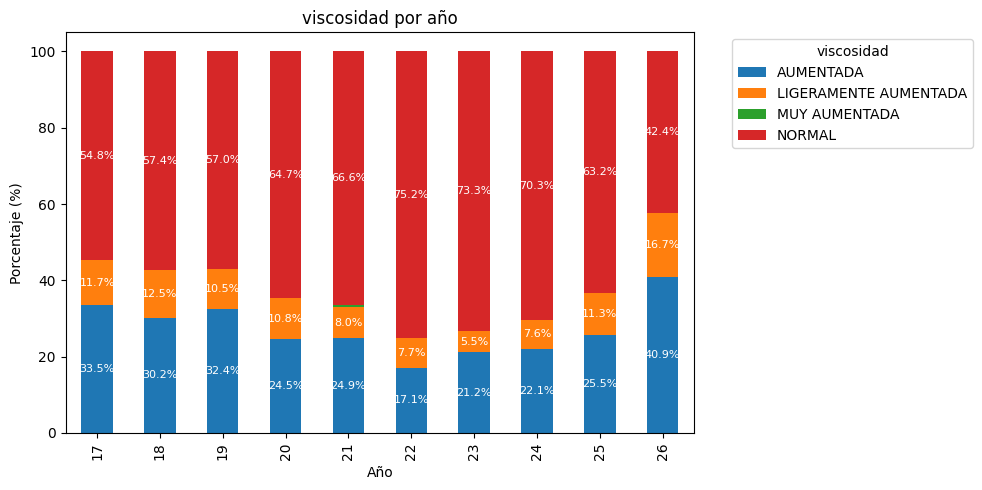

In [21]:
grafica_proporcion('viscosidad')

### **Chi2 en viscosidad y año**

In [22]:
chi_proporciones('viscosidad')

viscosidad,AUMENTADA,LIGERAMENTE AUMENTADA,MUY AUMENTADA,NORMAL
año,,,,
17,123,43,0,201
18,133,55,0,253
19,145,47,0,255
20,75,33,0,198
21,93,30,2,249
22,62,28,0,273
23,77,20,0,266
24,73,25,0,232
25,93,41,0,230


Chi² = 107.169
Grados de libertad = 27
p-value = 0.00000
V de Cramér = 0.102


### **Post-hoc en viscosidad**

In [23]:
tabla = pd.crosstab(df['año'], df['viscosidad'])

chi2, p, gl, esperados = chi2_contingency(tabla)

residuos = (tabla - esperados) / esperados**0.5

display(residuos.round(2))

viscosidad,AUMENTADA,LIGERAMENTE AUMENTADA,MUY AUMENTADA,NORMAL
año,,,,
17,2.68,1.22,-0.46,-2.18
18,1.56,1.84,-0.51,-1.71
19,2.51,0.53,-0.51,-1.81
20,-0.62,0.59,-0.42,0.18
21,-0.55,-1.06,3.81,0.66
22,-3.44,-1.23,-0.46,2.70
23,-1.90,-2.58,-0.46,2.24
24,-1.49,-1.26,-0.44,1.46
25,-0.29,0.94,-0.46,-0.16


## **Mucolisis por año**


Distribución porcentual del diagnóstico por año


mucolisis,COMPLETA,INCOMPLETA
año,,
17,59.95,40.05
18,59.64,40.36
19,62.64,37.36
20,68.95,31.05
21,71.66,28.34
22,79.06,20.94
23,74.59,25.41
24,71.52,28.48
25,71.70,28.30


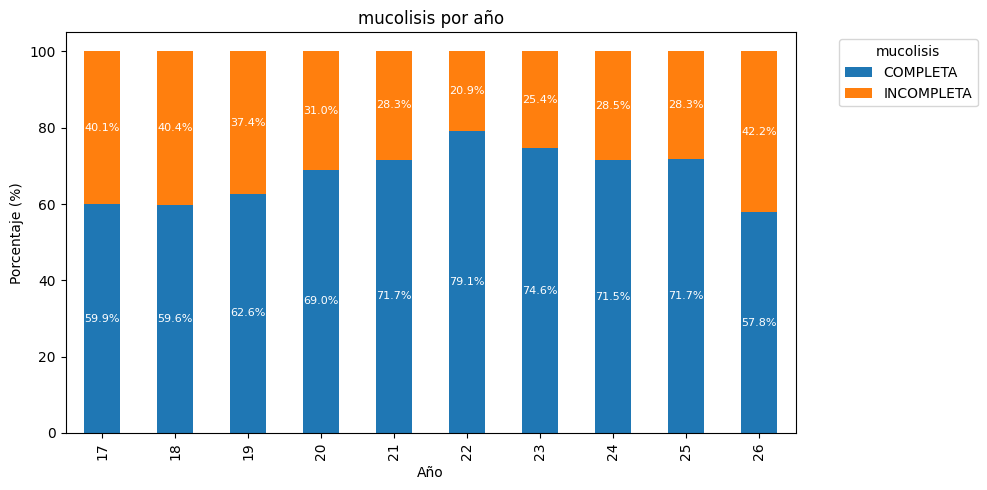

In [24]:
grafica_proporcion('mucolisis')

### **Chi2 en mucolisis**

In [25]:
chi_proporciones('mucolisis')

mucolisis,COMPLETA,INCOMPLETA
año,,
17,220,147
18,263,178
19,280,167
20,211,95
21,268,106
22,287,76
23,270,92
24,236,94
25,261,103


Chi² = 69.358
Grados de libertad = 9
p-value = 0.00000
V de Cramér = 0.142


### **Post-hoc en mucolisis**

In [26]:
tabla = pd.crosstab(df['año'], df['mucolisis'])

chi2, p, gl, esperados = chi2_contingency(tabla)

residuos = (tabla - esperados) / esperados**0.5

display(residuos.round(2))

mucolisis,COMPLETA,INCOMPLETA
año,,
17,-1.91,2.80
18,-2.18,3.19
19,-1.42,2.08
20,0.16,-0.23
21,0.81,-1.19
22,2.51,-3.67
23,1.47,-2.15
24,0.73,-1.07
25,0.81,-1.19


## **Examen bacterias por año**


Distribución porcentual del diagnóstico por año


examen_hora,BACTERIAS,BACTERIAS +,BACTERIAS ++,BACTERIAS +++,BACTERIAS ++++,BACTERIAS = 2000000,ESCASAS
año,,,,,,,
17,0.30,32.64,31.16,10.09,0.89,0.00,24.93
18,0.00,40.47,24.80,3.66,0.00,0.00,31.07
19,0.27,39.19,18.92,8.11,0.81,0.00,32.70
20,0.00,38.11,23.36,6.56,0.82,0.00,31.15
21,0.00,33.22,25.61,5.54,0.35,0.00,35.29
22,0.38,30.83,34.59,5.26,0.00,0.38,28.57
23,0.44,34.65,38.16,5.26,0.00,0.00,21.49
24,0.00,39.34,25.82,4.10,0.00,0.00,30.74
25,0.00,33.33,32.52,2.44,0.00,0.00,31.71


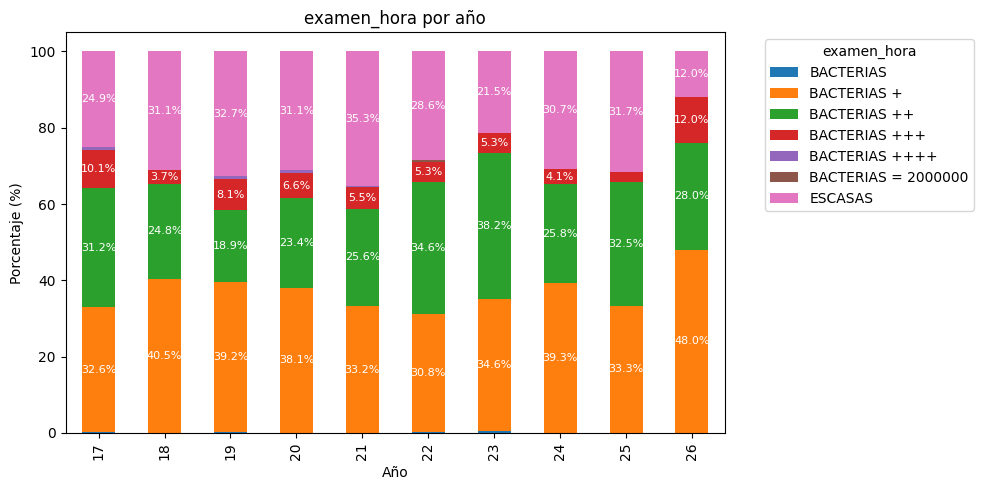

In [27]:
grafica_proporcion('examen_hora')

### **Chi2 en examen bacterias**

In [28]:
chi_proporciones('examen_hora')

examen_hora,BACTERIAS,BACTERIAS +,BACTERIAS ++,BACTERIAS +++,BACTERIAS ++++,BACTERIAS = 2000000,ESCASAS
año,,,,,,,
17,1,110,105,34,3,0,84
18,0,155,95,14,0,0,119
19,1,145,70,30,3,0,121
20,0,93,57,16,2,0,76
21,0,96,74,16,1,0,102
22,1,82,92,14,0,1,76
23,1,79,87,12,0,0,49
24,0,96,63,10,0,0,75
25,0,41,40,3,0,0,39


Chi² = 100.154
Grados de libertad = 54
p-value = 0.00014
V de Cramér = 0.082


### **Post-hoc en examen bacterias**

In [29]:
tabla = pd.crosstab(df['año'], df['examen_hora'])

chi2, p, gl, esperados = chi2_contingency(tabla)

residuos = (tabla - esperados) / esperados**0.5

display(residuos.round(2))

examen_hora,BACTERIAS,BACTERIAS +,BACTERIAS ++,BACTERIAS +++,BACTERIAS ++++,BACTERIAS = 2000000,ESCASAS
año,,,,,,,
17,0.63,-1.09,1.28,3.01,1.63,-0.37,-1.59
18,-0.78,1.38,-1.01,-1.91,-1.17,-0.39,0.51
19,0.53,0.95,-3.15,1.60,1.45,-0.38,1.08
20,-0.62,0.49,-1.23,0.32,1.20,-0.31,0.43
21,-0.68,-0.85,-0.61,-0.36,-0.04,-0.34,1.76
22,0.88,-1.46,2.20,-0.53,-0.98,2.75,-0.32
23,1.06,-0.40,3.07,-0.49,-0.90,-0.30,-2.26
24,-0.62,0.81,-0.50,-1.24,-0.94,-0.31,0.31
25,-0.44,-0.53,1.06,-1.63,-0.66,-0.22,0.42


## **Trazas gel por año**


Distribución porcentual del diagnóstico por año


trazas_gel,NO,SI
año,,
17,98.64,1.36
18,97.07,2.93
19,96.45,3.55
20,98.06,1.94
21,98.15,1.85
22,98.38,1.62
23,98.63,1.37
24,97.62,2.38
25,94.26,5.74


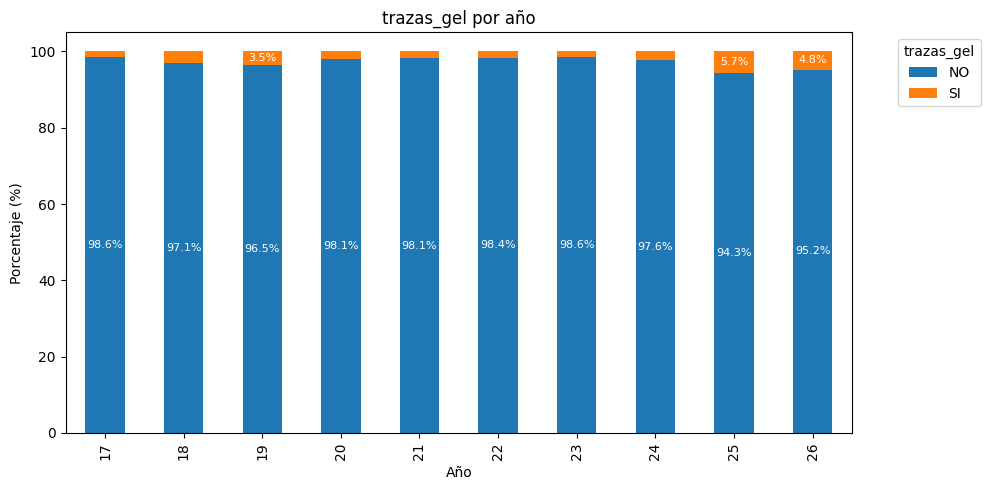

In [30]:
grafica_proporcion('trazas_gel')

### **Chi2 en trazas de gel**

In [31]:
chi_proporciones('trazas_gel')

trazas_gel,NO,SI
año,,
17,362,5
18,430,13
19,435,16
20,304,6
21,371,7
22,364,6
23,361,5
24,328,8
25,345,21


Chi² = 24.626
Grados de libertad = 9
p-value = 0.00341
V de Cramér = 0.084


In [32]:
df_sin_texto = df.copy()

df_sin_texto['celulas_redondas'] = pd.to_numeric(
    df_sin_texto['celulas_redondas'],
    errors='coerce'
)

df_sin_texto['aglutinacion_pct'] = pd.to_numeric(
    df_sin_texto['aglutinacion_pct'],
    errors='coerce'
)

## **Variables numéricas - Kruskal Wallis & Post-hoc**

### **Edad**

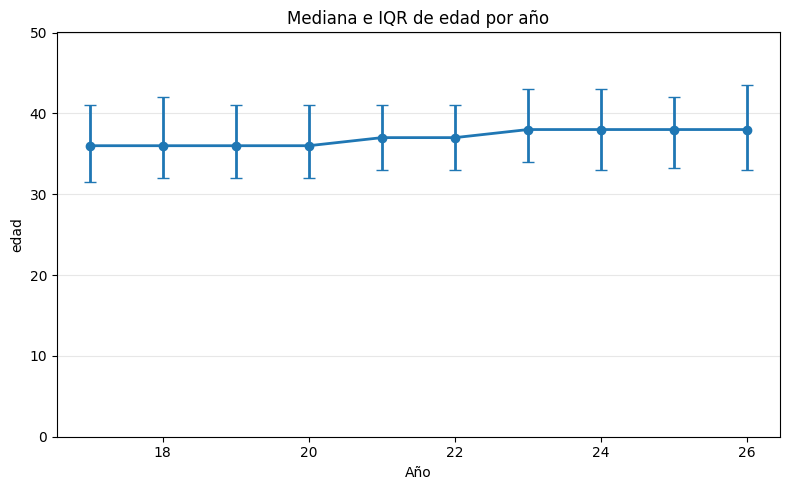

,n,media,mediana,min,max,sd,var,q1,q3,skewness
año,,,,,,,,,,
17,367,36.64,36.00,21.00,63.00,7.00,48.95,31.50,41.00,0.51
18,443,37.44,36.00,20.00,68.00,7.48,55.94,32.00,42.00,0.86
19,451,37.14,36.00,21.00,69.00,7.25,52.52,32.00,41.00,0.83
20,310,37.22,36.00,22.00,73.00,7.22,52.08,32.00,41.00,1.10
21,378,36.98,37.00,17.00,68.00,7.32,53.51,33.00,41.00,0.71
22,370,37.74,37.00,20.00,67.00,7.23,52.21,33.00,41.00,0.96
23,366,38.85,38.00,21.00,69.00,7.56,57.23,34.00,43.00,0.89
24,336,38.75,38.00,21.00,67.00,8.08,65.30,33.00,43.00,0.68
25,366,38.25,38.00,21.00,66.00,7.32,53.61,33.25,42.00,0.82


In [33]:
def graficas_numericas(var):

    resumen = (
        df_sin_texto
        .groupby('año')[var]
        .agg(
            mediana='median',
            q1=lambda x: x.quantile(0.25),
            q3=lambda x: x.quantile(0.75),
            n='count',
            media='mean',
            sd='std'
        )
        .reset_index()
    )

    # Distancia desde la mediana hasta Q1 y Q3
    error = [
        resumen['mediana'] - resumen['q1'],
        resumen['q3'] - resumen['mediana']
    ]

    plt.figure(figsize=(8,5))

    plt.errorbar(
        resumen['año'],
        resumen['mediana'],
        yerr=error,
        fmt='o-',
        capsize=4,
        linewidth=2,
        markersize=6
    )

    plt.xlabel("Año")
    plt.ylabel(var)
    plt.ylim(
    0,
    resumen['q3'].max() * 1.15
)
    plt.title(f"Mediana e IQR de {var} por año")

    plt.grid(axis='y', alpha=.3)

    plt.tight_layout()
    plt.show()

    tabla = (
        df_sin_texto
        .groupby('año')[var]
        .agg(
            n='count',
            media='mean',
            mediana='median',
            min='min',
            max='max',
            sd='std',
            var='var',
            q1=lambda x: x.quantile(0.25),
            q3=lambda x: x.quantile(0.75),
            skewness='skew'
        )
        .round(2)
    )

    display(tabla)

graficas_numericas('edad')

In [34]:
def kruskal_var(var):
    grupos = []

    for _, grupo in df_sin_texto.groupby('año'):
        grupos.append(
            grupo[var].dropna().values
        ) 

    stat, p = kruskal(*grupos) 

    print("Kruskal-Wallis")
    print(f"H = {stat:.4f}")
    print(f"p = {p:.6f}")

kruskal_var('edad')

Kruskal-Wallis
H = 34.0172
p = 0.000089


In [35]:
def post_hoc_dunn(var):
    dunn = sp.posthoc_dunn(
    df_sin_texto,
    val_col=var,
    group_col='año',
    p_adjust='bonferroni'   
)

    sig = (
        dunn.where(np.triu(np.ones(dunn.shape), k=1).astype(bool))
            .stack()
            .reset_index()
    )

    sig.columns = ['año_1', 'año_2', 'p-valor']

    sig = sig[sig['p-valor'] < 0.05]

    display(sig.sort_values('p-valor'))

post_hoc_dunn('edad')

,año_1,año_2,p-valor
5,17,23,0.00
20,19,23,0.03
6,17,24,0.03
26,20,23,0.04


### **Dias abstinencia**

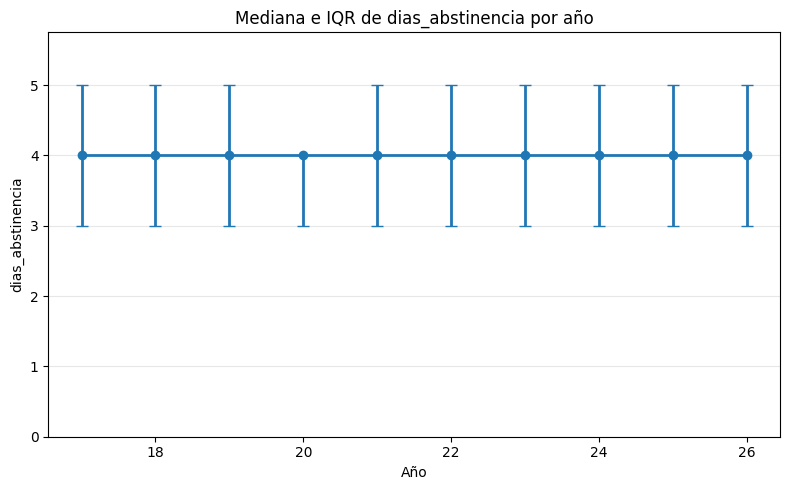

,n,media,mediana,min,max,sd,var,q1,q3,skewness
año,,,,,,,,,,
17,367,3.89,4.00,1,10,1.09,1.19,3.00,5.00,1.04
18,443,4.08,4.00,1,45,3.38,11.39,3.00,5.00,9.68
19,451,3.94,4.00,0,20,1.36,1.84,3.00,5.00,3.92
20,310,3.97,4.00,1,30,1.85,3.42,3.00,4.00,9.35
21,378,4.12,4.00,1,40,2.27,5.16,3.00,5.00,10.90
22,370,4.15,4.00,1,15,1.61,2.59,3.00,5.00,3.44
23,366,4.10,4.00,0,10,1.33,1.76,3.00,5.00,0.74
24,336,4.16,4.00,1,60,3.73,13.88,3.00,5.00,11.44
25,366,4.06,4.00,1,30,2.02,4.07,3.00,5.00,6.40


In [36]:
graficas_numericas('dias_abstinencia')

In [37]:
kruskal_var('dias_abstinencia')

Kruskal-Wallis
H = 22.3635
p = 0.007796


In [38]:
post_hoc_dunn('dias_abstinencia')

,año_1,año_2,p-valor
13,18,23,0.03
12,18,22,0.04


### **Volumen**

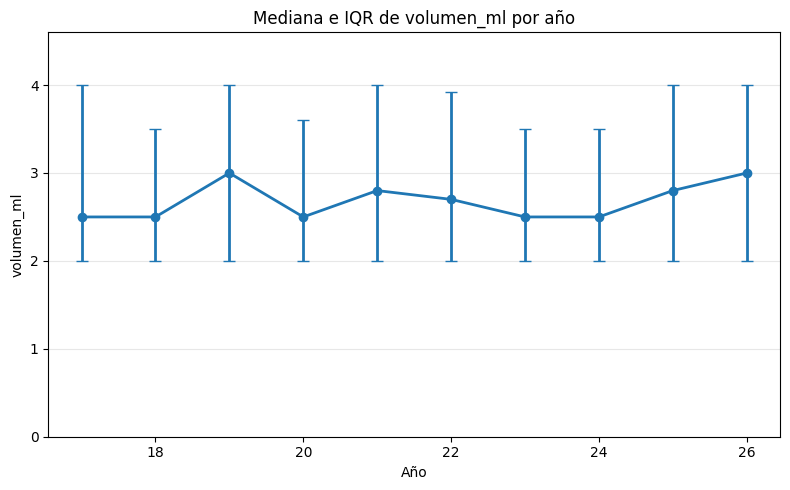

,n,media,mediana,min,max,sd,var,q1,q3,skewness
año,,,,,,,,,,
17,367,2.82,2.50,0.20,8.50,1.51,2.27,2.00,4.00,0.87
18,443,2.85,2.50,0.10,9.00,1.46,2.14,2.00,3.50,0.82
19,450,3.00,3.00,0.30,9.50,1.43,2.03,2.00,4.00,1.13
20,309,2.80,2.50,0.40,8.50,1.41,1.99,2.00,3.60,0.98
21,378,2.94,2.80,0.30,9.50,1.54,2.38,2.00,4.00,0.90
22,370,2.94,2.70,0.25,14.00,1.57,2.47,2.00,3.92,1.48
23,364,2.83,2.50,0.20,11.50,1.53,2.34,2.00,3.50,1.35
24,336,2.75,2.50,0.30,9.50,1.37,1.88,2.00,3.50,1.08
25,366,3.00,2.80,0.10,8.00,1.48,2.20,2.00,4.00,0.61


In [39]:
graficas_numericas('volumen_ml')

In [40]:
kruskal_var('volumen_ml')

Kruskal-Wallis
H = 13.6759
p = 0.134331


### **Ph**

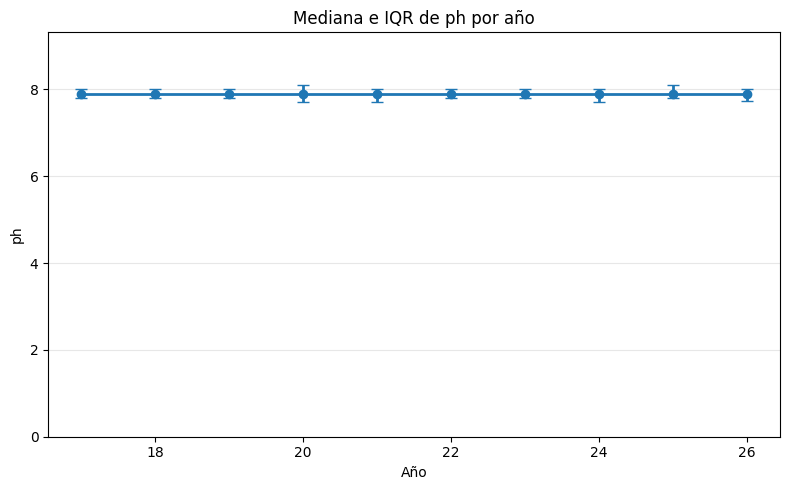

,n,media,mediana,min,max,sd,var,q1,q3,skewness
año,,,,,,,,,,
17,364,7.83,7.90,2.00,8.50,0.40,0.16,7.80,8.00,-8.96
18,408,7.91,7.90,6.50,9.00,0.26,0.07,7.80,8.00,-0.62
19,402,7.89,7.90,6.50,8.50,0.25,0.06,7.80,8.00,-1.26
20,274,7.86,7.90,6.50,8.50,0.29,0.08,7.70,8.10,-1.38
21,321,7.88,7.90,6.50,9.00,0.26,0.07,7.70,8.00,-0.53
22,300,7.86,7.90,3.00,8.90,0.38,0.14,7.80,8.00,-7.27
23,274,7.90,7.90,6.80,8.50,0.22,0.05,7.80,8.00,-0.43
24,266,7.85,7.90,6.50,8.70,0.25,0.06,7.70,8.00,-1.01
25,287,7.92,7.90,6.70,9.00,0.27,0.07,7.80,8.10,-0.61


In [41]:
graficas_numericas('ph')

In [42]:
kruskal_var('ph')

Kruskal-Wallis
H = 26.2458
p = 0.001862


In [43]:
post_hoc_dunn('ph')

,año_1,año_2,p-valor
42,24,25,0.04
7,17,25,0.05


### **Celulas redondas**

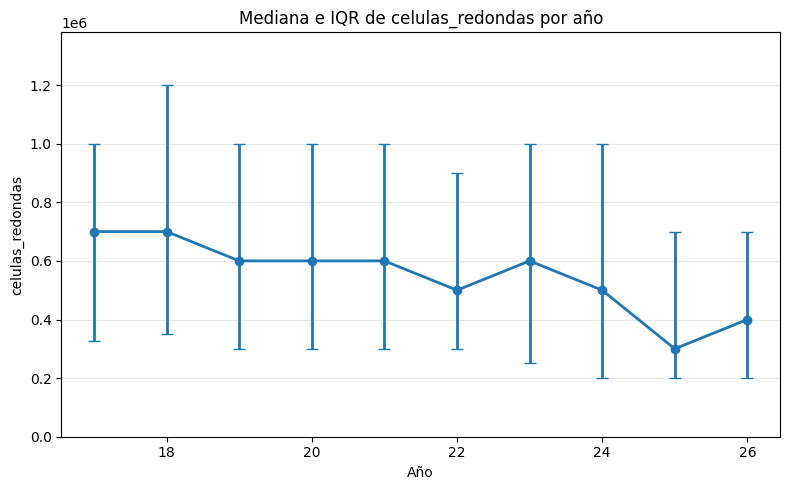

,n,media,mediana,min,max,sd,var,q1,q3,skewness
año,,,,,,,,,,
17,350,"917,428.57","700,000.00","100,000.00","6,300,000.00","954,950.43","911,930,331,559.56","325,000.00","1,000,000.00",3.13
18,411,"1,140,676.40","700,000.00","100,000.00","16,000,000.00","1,642,179.02","2,696,751,941,368.47","350,000.00","1,200,000.00",5.00
19,425,"1,133,647.06","600,000.00",0.00,"22,000,000.00","2,164,959.39","4,687,049,167,591.57","300,000.00","1,000,000.00",6.67
20,291,"1,049,484.54","600,000.00","100,000.00","23,000,000.00","2,003,881.94","4,015,542,836,829.01","300,000.00","1,000,000.00",6.88
21,360,"969,444.44","600,000.00",0.00,"28,000,000.00","1,850,065.04","3,422,740,637,573.51","300,000.00","1,000,000.00",9.76
22,333,"810,510.51","500,000.00",0.00,"11,000,000.00","1,230,428.97","1,513,955,461,485.58","300,000.00","900,000.00",5.28
23,323,"971,207.43","600,000.00",0.00,"13,000,000.00","1,338,398.77","1,791,311,270,503.62","250,000.00","1,000,000.00",4.45
24,308,"925,974.03","500,000.00","100,000.00","11,800,000.00","1,449,083.96","2,099,844,325,056.05","200,000.00","1,000,000.00",4.36
25,339,"590,855.46","300,000.00","100,000.00","7,000,000.00","765,764.60","586,395,419,873.98","200,000.00","700,000.00",3.51


In [44]:
graficas_numericas('celulas_redondas')

In [45]:
kruskal_var('celulas_redondas')

Kruskal-Wallis
H = 110.5974
p = 0.000000


In [46]:
post_hoc_dunn('celulas_redondas')

,año_1,año_2,p-valor
15,18,25,0.00
7,17,25,0.00
22,19,25,0.00
40,23,25,0.00
33,21,25,0.00
28,20,25,0.00
12,18,22,0.00
16,18,26,0.00
14,18,24,0.00
42,24,25,0.00


### **Aglutinación**

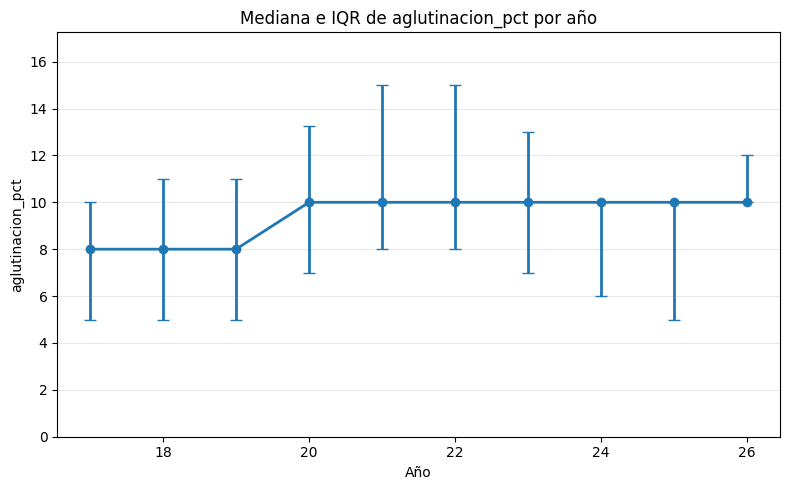

,n,media,mediana,min,max,sd,var,q1,q3,skewness
año,,,,,,,,,,
17,244,9.14,8.00,0.00,24.00,5.04,25.44,5.00,10.00,0.78
18,197,9.10,8.00,0.00,35.00,5.27,27.75,5.00,11.00,1.61
19,187,9.96,8.00,0.00,70.00,7.00,49.06,5.00,11.00,4.41
20,112,10.67,10.00,0.00,40.00,5.56,30.96,7.00,13.25,1.88
21,141,11.21,10.00,4.00,30.00,5.52,30.45,8.00,15.00,1.24
22,118,11.44,10.00,0.00,35.00,5.99,35.86,8.00,15.00,1.34
23,87,10.38,10.00,0.00,28.00,4.52,20.45,7.00,13.00,0.91
24,100,9.42,10.00,0.00,25.00,4.38,19.18,6.00,10.00,1.22
25,125,9.09,10.00,0.00,30.00,4.83,23.37,5.00,10.00,1.44


In [47]:
graficas_numericas('aglutinacion_pct')

In [48]:
kruskal_var('aglutinacion_pct')

Kruskal-Wallis
H = 45.7145
p = 0.000001


In [49]:
post_hoc_dunn('aglutinacion_pct')

,año_1,año_2,p-valor


### **Total eyaculado**

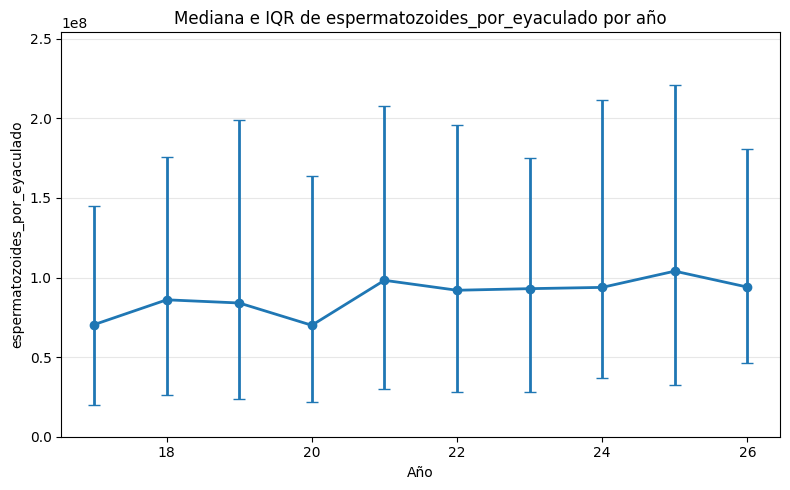

,n,media,mediana,min,max,sd,var,q1,q3,skewness
año,,,,,,,,,,
17,367,"96,064,087.19","70,400,000.00",0.00,"704,000,000.00","99,251,200.64","9,850,800,829,150,852.00","20,000,000.00","145,000,000.00",1.79
18,443,"124,262,618.51","86,000,000.00",0.00,"972,000,000.00","131,463,130.34","17,282,554,638,829,266.00","26,300,000.00","175,500,000.00",1.87
19,451,"126,628,736.14","84,000,000.00",0.00,"612,000,000.00","128,933,155.39","16,623,758,557,732,446.00","23,700,000.00","199,000,000.00",1.27
20,309,"115,808,317.15","70,000,000.00",0.00,"799,500,000.00","130,268,585.70","16,969,904,421,184,804.00","22,000,000.00","164,000,000.00",1.95
21,378,"144,475,211.64","98,250,000.00",0.00,"896,000,000.00","149,551,793.40","22,365,738,909,371,524.00","30,000,000.00","207,875,000.00",1.56
22,370,"133,987,621.62","92,000,000.00",0.00,"1,599,000,000.00","149,746,425.78","22,423,992,032,810,368.00","28,250,000.00","196,000,000.00",3.43
23,365,"125,262,575.34","93,000,000.00",0.00,"700,000,000.00","128,600,673.47","16,538,133,218,212,022.00","28,000,000.00","175,000,000.00",1.71
24,336,"132,354,032.74","93,800,000.00",0.00,"647,500,000.00","125,106,837.73","15,651,720,845,554,160.00","36,600,000.00","211,500,000.00",1.28
25,366,"156,012,909.84","104,000,000.00",0.00,"886,500,000.00","159,267,460.89","25,366,124,098,153,520.00","32,425,000.00","220,875,000.00",1.61


In [50]:
graficas_numericas('espermatozoides_por_eyaculado')

In [51]:
kruskal_var('espermatozoides_por_eyaculado')

Kruskal-Wallis
H = 34.7911
p = 0.000065


In [52]:
post_hoc_dunn('espermatozoides_por_eyaculado')

,año_1,año_2,p-valor
7,17,25,0.00
3,17,21,0.00
6,17,24,0.01
28,20,25,0.02
4,17,22,0.05


### **Concentración eyaculado**

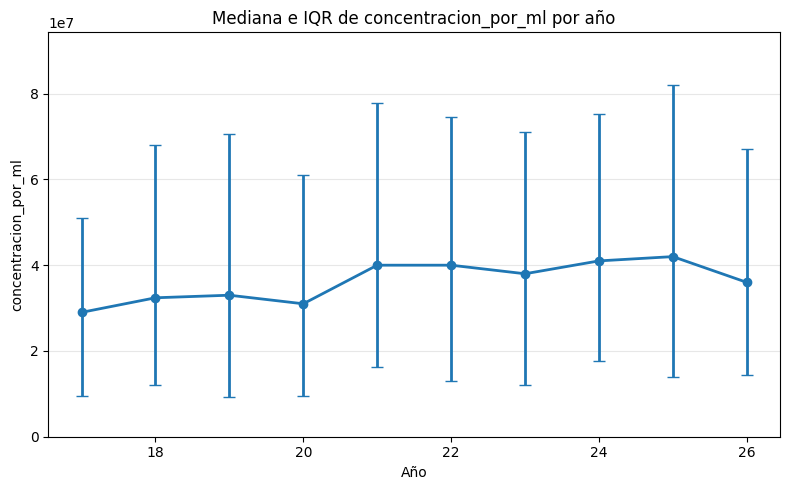

,n,media,mediana,min,max,sd,var,q1,q3,skewness
año,,,,,,,,,,
17,367,"35,812,602.18","29,000,000.00",0.00,"190,000,000.00","32,475,358.98","1,054,648,940,819,448.75","9,500,000.00","51,000,000.00",1.15
18,443,"45,463,566.59","32,400,000.00",0.00,"238,000,000.00","41,784,716.04","1,745,962,494,490,464.75","12,000,000.00","68,000,000.00",1.16
19,451,"43,899,113.08","33,000,000.00",0.00,"181,000,000.00","40,164,793.29","1,613,210,619,656,073.50","9,200,000.00","70,500,000.00",0.93
20,309,"41,924,595.47","31,000,000.00",0.00,"280,000,000.00","41,572,653.23","1,728,285,496,994,915.00","9,600,000.00","61,000,000.00",1.69
21,378,"49,454,232.80","40,000,000.00",0.00,"220,000,000.00","42,710,359.36","1,824,174,796,359,451.00","16,250,000.00","77,750,000.00",1.01
22,370,"48,186,216.22","40,000,000.00",0.00,"293,000,000.00","44,830,397.63","2,009,764,552,039,843.75","13,000,000.00","74,500,000.00",1.59
23,365,"47,083,287.67","38,000,000.00",0.00,"210,000,000.00","42,439,631.11","1,801,122,288,612,073.50","12,000,000.00","71,000,000.00",1.16
24,336,"50,211,160.71","41,000,000.00",0.00,"214,000,000.00","42,188,640.00","1,779,881,345,215,884.25","17,750,000.00","75,250,000.00",1.03
25,366,"54,360,928.96","42,000,000.00",0.00,"300,400,000.00","49,000,985.91","2,401,096,619,956,585.00","14,000,000.00","82,000,000.00",1.25


In [53]:
graficas_numericas('concentracion_por_ml')

In [54]:
kruskal_var('concentracion_por_ml')

Kruskal-Wallis
H = 38.2056
p = 0.000016


In [55]:
post_hoc_dunn('concentracion_por_ml')

,año_1,año_2,p-valor
7,17,25,0.00
6,17,24,0.00
3,17,21,0.00
4,17,22,0.03
28,20,25,0.03


### **Test eosina**

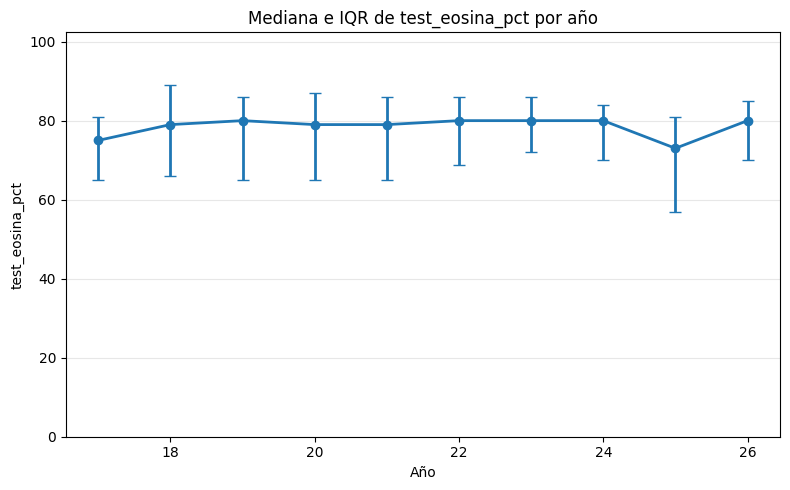

,n,media,mediana,min,max,sd,var,q1,q3,skewness
año,,,,,,,,,,
17,356,68.78,75.00,0.00,98.00,21.68,470.08,65.00,81.00,-2.03
18,405,72.98,79.00,0.00,98.00,22.70,515.25,66.00,89.00,-1.78
19,384,70.65,80.00,0.00,98.00,25.89,670.10,65.00,86.00,-1.74
20,257,70.32,79.00,0.00,97.00,24.86,618.09,65.00,87.00,-1.73
21,315,71.05,79.00,0.00,96.00,23.71,562.24,65.00,86.00,-1.69
22,292,71.99,80.00,0.00,98.00,24.01,576.64,68.75,86.00,-2.03
23,269,73.58,80.00,0.00,98.00,22.37,500.58,72.00,86.00,-2.18
24,257,71.26,80.00,0.00,96.00,22.24,494.64,70.00,84.00,-1.94
25,280,65.49,73.00,0.00,97.00,23.66,559.68,57.00,81.00,-1.42


In [56]:
graficas_numericas('test_eosina_pct')

In [57]:
kruskal_var('test_eosina_pct')

Kruskal-Wallis
H = 66.3164
p = 0.000000


In [58]:
post_hoc_dunn('test_eosina_pct')

,año_1,año_2,p-valor
40,23,25,0.00
15,18,25,0.00
22,19,25,0.00
37,22,25,0.00
5,17,23,0.00
0,17,18,0.00
33,21,25,0.01
1,17,19,0.02
28,20,25,0.03
4,17,22,0.03


### **Motilidad progresiva**

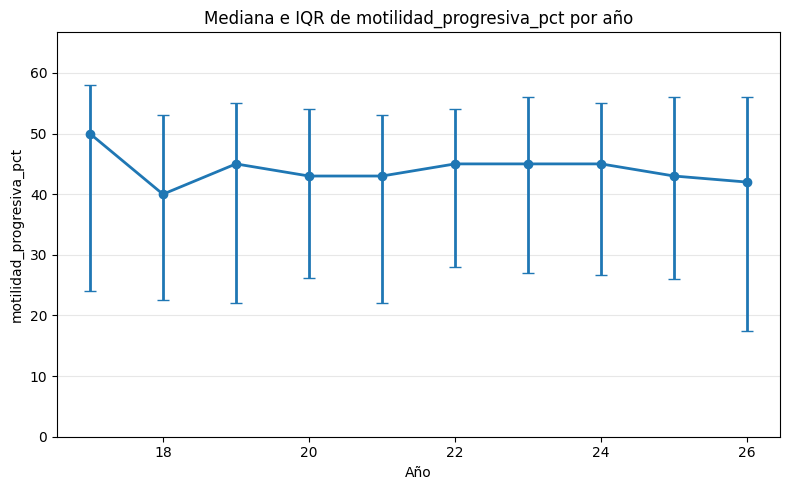

,n,media,mediana,min,max,sd,var,q1,q3,skewness
año,,,,,,,,,,
17,366,41.32,50.00,0.00,82.00,21.21,449.82,24.00,58.00,-0.61
18,443,37.31,40.00,0.00,84.00,20.45,418.18,22.50,53.00,-0.36
19,450,38.91,45.00,0.00,84.00,20.83,433.99,22.00,55.00,-0.48
20,310,39.06,43.00,0.00,78.00,20.02,400.72,26.25,54.00,-0.50
21,377,38.15,43.00,0.00,82.00,19.63,385.35,22.00,53.00,-0.47
22,370,39.59,45.00,0.00,84.00,19.49,379.82,28.00,54.00,-0.56
23,365,40.01,45.00,0.00,80.00,20.11,404.55,27.00,56.00,-0.55
24,336,40.50,45.00,0.00,78.00,19.25,370.40,26.75,55.00,-0.54
25,366,40.39,43.00,0.00,84.00,21.15,447.38,26.00,56.00,-0.34


In [59]:
graficas_numericas('motilidad_progresiva_pct')

In [60]:
kruskal_var('motilidad_progresiva_pct')

Kruskal-Wallis
H = 16.3435
p = 0.060046


In [61]:
post_hoc_dunn('motilidad_progresiva_pct')

,año_1,año_2,p-valor
0,17,18,0.02


### **Motilidad no progresiva**

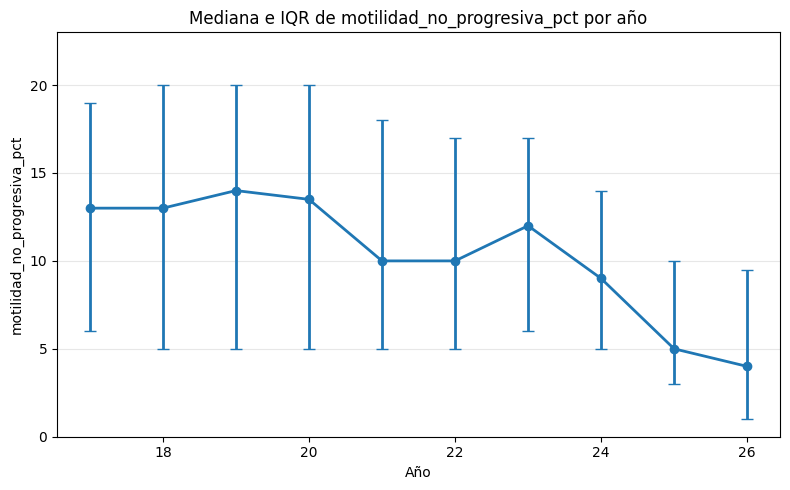

,n,media,mediana,min,max,sd,var,q1,q3,skewness
año,,,,,,,,,,
17,366,12.99,13.00,0.00,58.00,8.07,65.07,6.00,19.00,0.49
18,443,13.02,13.00,0.00,44.00,8.80,77.36,5.00,20.00,0.30
19,451,13.05,14.00,0.00,40.00,8.66,75.04,5.00,20.00,0.14
20,310,13.42,13.50,0.00,45.00,8.80,77.36,5.00,20.00,0.27
21,377,11.75,10.00,0.00,38.00,8.23,67.73,5.00,18.00,0.50
22,370,11.57,10.00,0.00,54.00,7.88,62.15,5.00,17.00,0.76
23,365,11.96,12.00,0.00,57.00,7.67,58.80,6.00,17.00,0.84
24,336,10.82,9.00,0.00,43.00,7.83,61.26,5.00,14.00,1.06
25,366,7.87,5.00,0.00,37.00,7.27,52.89,3.00,10.00,1.41


In [62]:
graficas_numericas('motilidad_no_progresiva_pct')

In [63]:
kruskal_var('motilidad_no_progresiva_pct')

Kruskal-Wallis
H = 157.1379
p = 0.000000


In [64]:
post_hoc_dunn('motilidad_no_progresiva_pct')

,año_1,año_2,p-valor
22,19,25,0.00
15,18,25,0.00
7,17,25,0.00
28,20,25,0.00
40,23,25,0.00
33,21,25,0.00
37,22,25,0.00
29,20,26,0.00
8,17,26,0.00
23,19,26,0.00


### **Inmoviles**

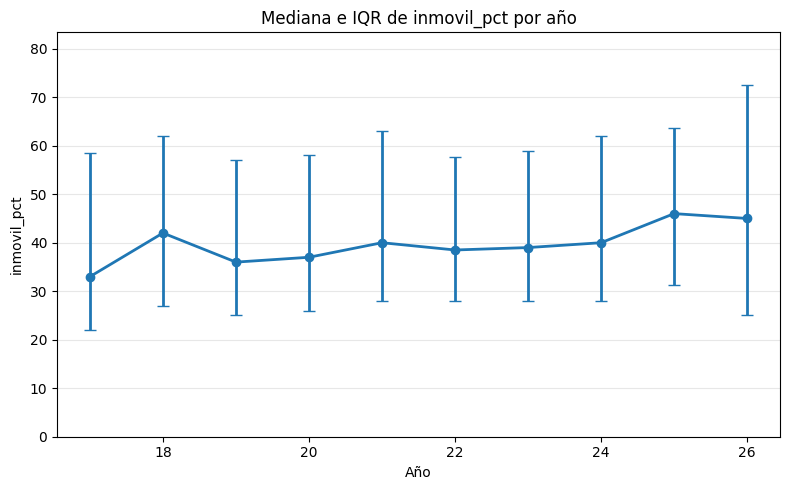

,n,media,mediana,min,max,sd,var,q1,q3,skewness
año,,,,,,,,,,
17,366,39.94,33.00,0.00,100.00,24.26,588.78,22.00,58.50,0.62
18,443,45.38,42.00,0.00,100.00,24.48,599.16,27.00,62.00,0.38
19,451,41.25,36.00,0.00,100.00,23.99,575.54,25.00,57.00,0.55
20,310,41.40,37.00,0.00,99.00,23.07,532.18,26.00,58.00,0.47
21,377,46.12,40.00,0.00,100.00,23.90,571.41,28.00,63.00,0.37
22,370,43.16,38.50,0.00,100.00,22.45,504.03,28.00,57.75,0.43
23,365,44.48,39.00,0.00,100.00,23.51,552.49,28.00,59.00,0.65
24,336,45.40,40.00,0.00,100.00,22.95,526.62,28.00,62.00,0.40
25,366,47.11,46.00,0.00,100.00,22.72,516.33,31.25,63.75,0.16


In [65]:
graficas_numericas('inmovil_pct')

In [66]:
kruskal_var('inmovil_pct')

Kruskal-Wallis
H = 46.7368
p = 0.000000


In [67]:
post_hoc_dunn('inmovil_pct')

,año_1,año_2,p-valor
7,17,25,0.00
22,19,25,0.00
3,17,21,0.00
0,17,18,0.00
6,17,24,0.01
28,20,25,0.01


### **Motilidad total**

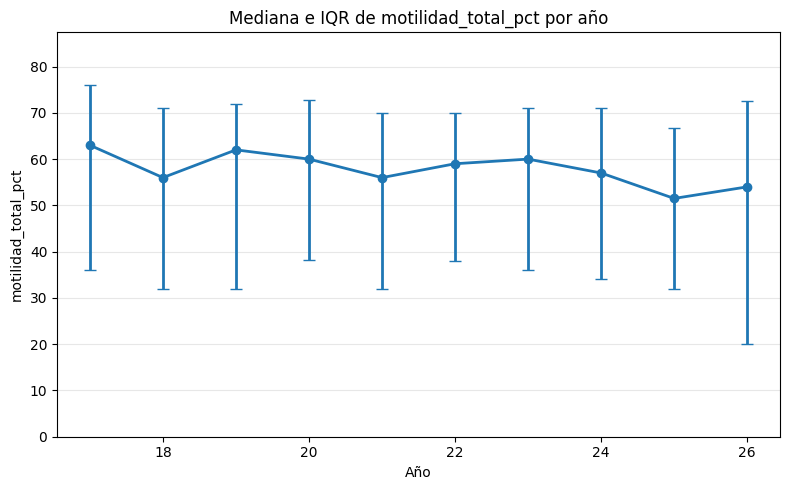

,n,media,mediana,min,max,sd,var,q1,q3,skewness
año,,,,,,,,,,
17,366,54.31,63.00,0.00,90.00,25.91,671.45,36.00,76.00,-0.76
18,443,50.32,56.00,0.00,89.00,24.91,620.69,32.00,71.00,-0.56
19,451,51.88,62.00,0.00,86.00,25.47,648.94,32.00,72.00,-0.77
20,310,52.47,60.00,0.00,89.00,24.51,600.55,38.25,72.75,-0.77
21,377,49.90,56.00,0.00,90.00,24.22,586.55,32.00,70.00,-0.57
22,370,51.16,59.00,0.00,86.00,23.44,549.52,38.00,70.00,-0.80
23,365,51.98,60.00,0.00,90.00,24.10,580.89,36.00,71.00,-0.81
24,336,51.32,57.00,0.00,88.00,23.36,545.70,34.00,71.00,-0.62
25,366,48.26,51.50,0.00,91.00,22.84,521.56,32.00,66.75,-0.53


In [68]:
graficas_numericas('motilidad_total_pct')

In [69]:
kruskal_var('motilidad_total_pct')

Kruskal-Wallis
H = 30.2146
p = 0.000403


In [70]:
post_hoc_dunn('motilidad_total_pct')

,año_1,año_2,p-valor
7,17,25,0.00
3,17,21,0.03


### **Normales**

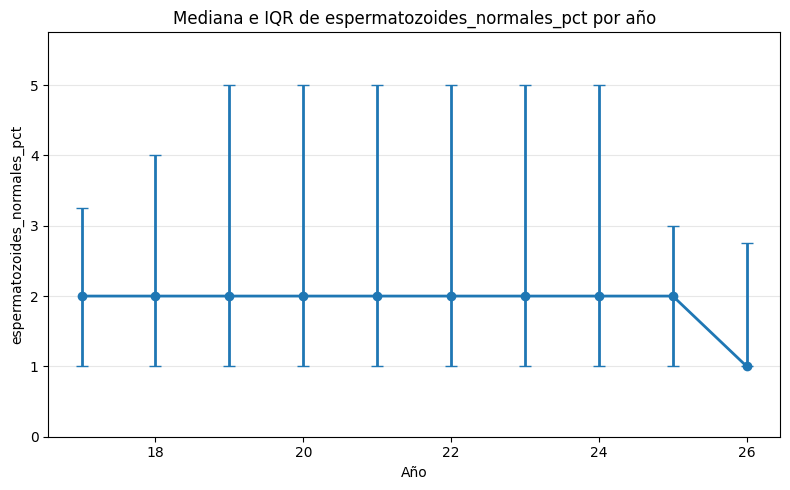

,n,media,mediana,min,max,sd,var,q1,q3,skewness
año,,,,,,,,,,
17,356,2.44,2.00,0.00,12.00,2.25,5.05,1.00,3.25,1.70
18,399,3.08,2.00,0.00,20.00,2.89,8.38,1.00,4.00,1.67
19,382,2.97,2.00,0.00,15.00,2.64,6.99,1.00,5.00,0.98
20,257,3.08,2.00,0.00,19.00,2.98,8.88,1.00,5.00,1.55
21,305,3.02,2.00,0.00,13.00,2.36,5.57,1.00,5.00,0.83
22,288,4.16,2.00,0.00,98.00,10.27,105.55,1.00,5.00,8.08
23,263,3.45,2.00,0.00,96.00,6.24,38.91,1.00,5.00,12.60
24,256,3.09,2.00,0.00,10.00,2.31,5.33,1.00,5.00,0.75
25,276,2.41,2.00,0.00,10.00,1.97,3.88,1.00,3.00,1.27


In [71]:
graficas_numericas('espermatozoides_normales_pct')

In [72]:
kruskal_var('espermatozoides_normales_pct')

Kruskal-Wallis
H = 40.8717
p = 0.000005


In [73]:
post_hoc_dunn('espermatozoides_normales_pct')

,año_1,año_2,p-valor
43,24,26,0.04


### **Anormales**

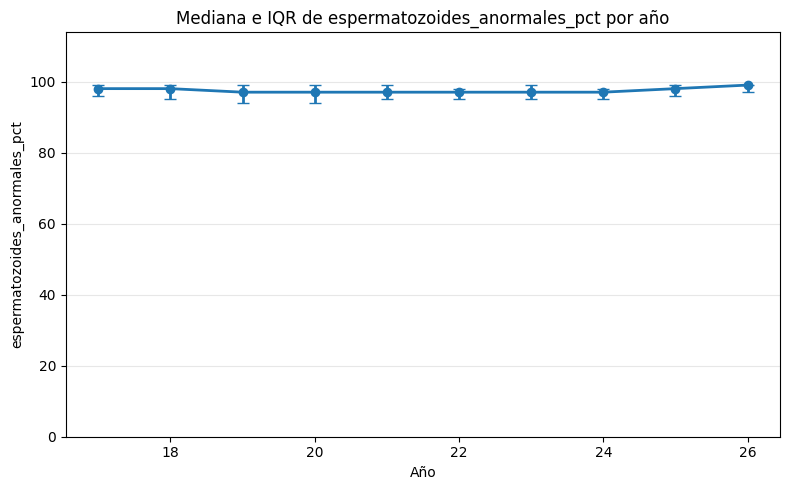

,n,media,mediana,min,max,sd,var,q1,q3,skewness
año,,,,,,,,,,
17,356,91.66,98.00,0.00,100.00,23.08,532.83,96.00,99.00,-3.70
18,399,92.41,98.00,0.00,100.00,20.31,412.42,95.00,99.00,-4.27
19,382,88.65,97.00,0.00,100.00,26.96,726.66,94.00,99.00,-2.97
20,257,89.53,97.00,0.00,100.00,25.51,650.51,94.00,99.00,-3.21
21,304,92.04,97.00,0.00,100.00,21.12,446.22,95.00,99.00,-4.10
22,288,88.55,97.00,0.00,100.00,26.89,723.03,95.00,98.00,-2.95
23,263,91.23,97.00,0.00,100.00,22.54,507.96,95.00,99.00,-3.77
24,256,92.23,97.00,0.00,100.00,20.61,424.81,95.00,98.00,-4.23
25,276,91.79,98.00,0.00,100.00,22.89,523.89,96.00,99.00,-3.76


In [74]:
graficas_numericas('espermatozoides_anormales_pct')

In [75]:
kruskal_var('espermatozoides_anormales_pct')

Kruskal-Wallis
H = 42.1074
p = 0.000003


In [76]:
post_hoc_dunn('espermatozoides_anormales_pct')

,año_1,año_2,p-valor
38,22,26,0.04


### **Alteración cabeza**

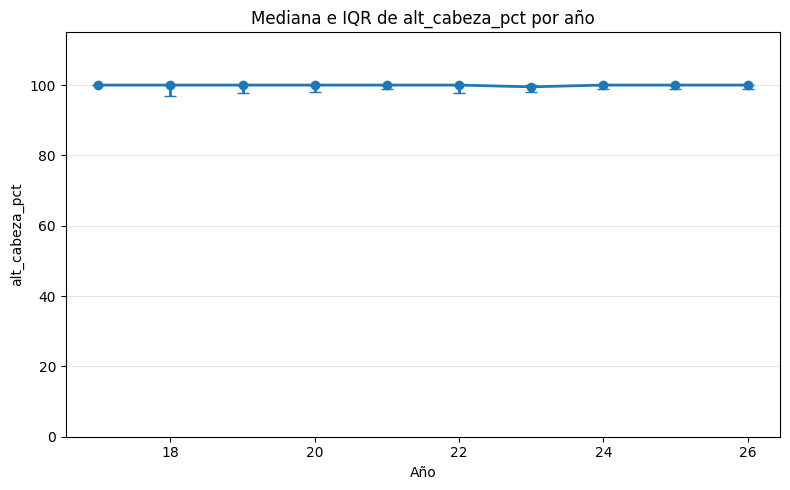

,n,media,mediana,min,max,sd,var,q1,q3,skewness
año,,,,,,,,,,
17,356,93.80,100.00,0.00,100.00,23.62,557.69,100.00,100.00,-3.72
18,399,93.08,100.00,0.00,100.00,20.86,434.98,96.76,100.00,-4.04
19,379,90.18,100.00,0.00,100.00,27.89,777.94,97.83,100.00,-2.91
20,256,91.61,100.00,0.00,100.00,26.07,679.43,97.91,100.00,-3.24
21,304,93.98,100.00,0.00,100.00,21.67,469.48,98.90,100.00,-4.07
22,287,91.26,100.00,0.00,100.00,25.92,671.61,97.86,100.00,-3.15
23,262,92.98,99.50,0.00,100.00,23.29,542.56,97.94,100.00,-3.69
24,256,94.67,100.00,0.00,100.00,21.06,443.60,98.92,100.00,-4.30
25,276,93.73,100.00,0.00,100.00,23.32,543.92,98.97,100.00,-3.79


In [77]:
graficas_numericas('alt_cabeza_pct')

In [78]:
kruskal_var('alt_cabeza_pct')

Kruskal-Wallis
H = 132.4108
p = 0.000000


In [79]:
post_hoc_dunn('alt_cabeza_pct')

,año_1,año_2,p-valor
0,17,18,0.00
1,17,19,0.00
4,17,22,0.00
5,17,23,0.00
2,17,20,0.00
3,17,21,0.00
6,17,24,0.00
37,22,25,0.01
15,18,25,0.01
22,19,25,0.02


### **Alteración cola**

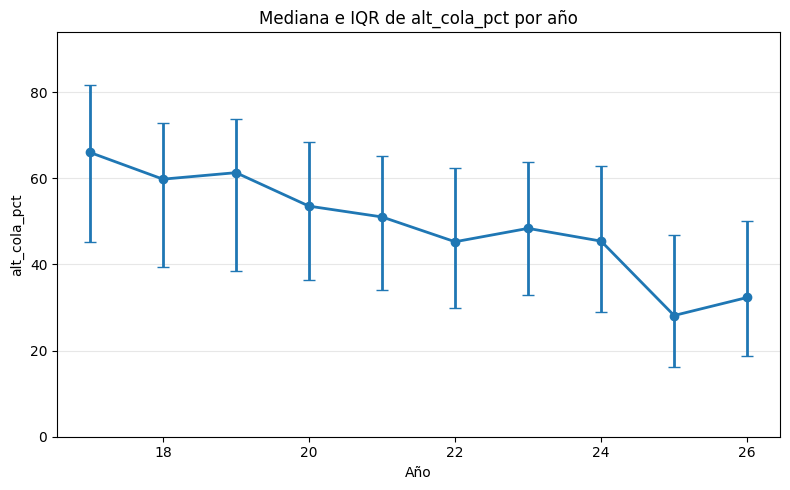

,n,media,mediana,min,max,sd,var,q1,q3,skewness
año,,,,,,,,,,
17,351,60.30,66.00,0.00,92.00,25.73,662.23,45.18,81.63,-0.93
18,400,55.58,59.79,0.00,100.00,23.18,537.47,39.32,72.77,-0.54
19,376,54.82,61.30,0.00,97.89,24.93,621.27,38.50,73.73,-0.79
20,255,50.50,53.53,0.00,95.91,23.03,530.17,36.33,68.48,-0.58
21,304,50.18,51.02,0.00,100.00,21.99,483.44,34.18,65.07,-0.25
22,287,45.02,45.26,0.00,100.00,21.94,481.32,29.94,62.31,-0.21
23,262,47.14,48.36,0.00,97.84,21.13,446.62,32.80,63.82,-0.33
24,256,44.92,45.40,0.00,89.13,21.14,446.86,28.99,62.94,-0.20
25,276,33.29,28.14,0.00,84.00,21.87,478.18,16.16,46.80,0.59


In [80]:
graficas_numericas('alt_cola_pct')

In [81]:
kruskal_var('alt_cola_pct')

Kruskal-Wallis
H = 306.3142
p = 0.000000


In [82]:
post_hoc_dunn('alt_cola_pct')

,año_1,año_2,p-valor
7,17,25,0.00
15,18,25,0.00
22,19,25,0.00
4,17,22,0.00
6,17,24,0.00
28,20,25,0.00
33,21,25,0.00
8,17,26,0.00
5,17,23,0.00
40,23,25,0.00


### **Alteración pieza intermedia**

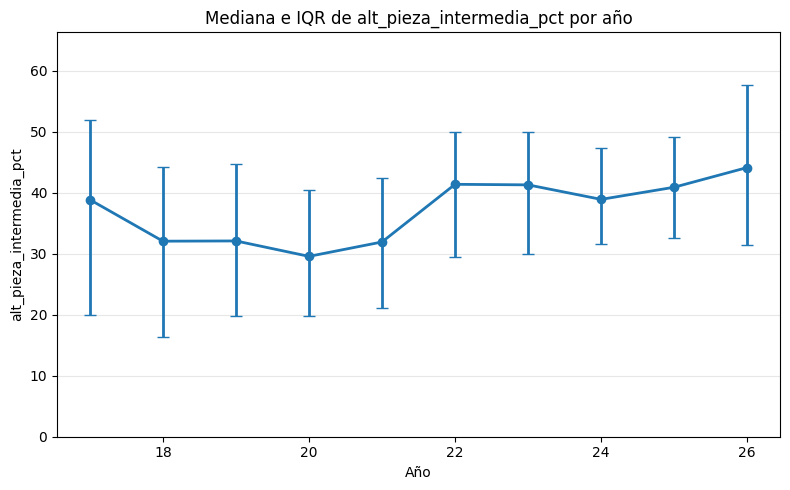

,n,media,mediana,min,max,sd,var,q1,q3,skewness
año,,,,,,,,,,
17,356,36.93,38.89,0.00,79.30,20.56,422.74,19.95,52.04,-0.01
18,400,32.63,32.08,0.00,95.90,19.11,365.04,16.32,44.24,0.43
19,380,32.07,32.12,0.00,84.00,18.25,332.90,19.77,44.71,0.13
20,255,30.00,29.59,0.00,77.00,16.31,265.86,19.78,40.40,0.25
21,304,32.53,31.95,0.00,89.17,16.37,268.11,21.20,42.53,0.32
22,287,39.77,41.41,0.00,98.00,18.19,330.88,29.46,50.00,-0.27
23,262,39.29,41.32,0.00,85.26,16.15,260.81,30.05,50.00,-0.39
24,256,38.47,38.94,0.00,74.00,14.65,214.57,31.57,47.43,-0.49
25,276,40.69,40.93,0.00,88.88,16.72,279.56,32.64,49.10,-0.34


In [83]:
graficas_numericas('alt_pieza_intermedia_pct')

In [84]:
kruskal_var('alt_pieza_intermedia_pct')

Kruskal-Wallis
H = 153.4041
p = 0.000000


In [85]:
post_hoc_dunn('alt_pieza_intermedia_pct')

,año_1,año_2,p-valor
28,20,25,0.00
25,20,22,0.00
26,20,23,0.00
15,18,25,0.00
22,19,25,0.00
33,21,25,0.00
27,20,24,0.00
19,19,22,0.00
12,18,22,0.00
30,21,22,0.00


### **Indice teratozoospermia**

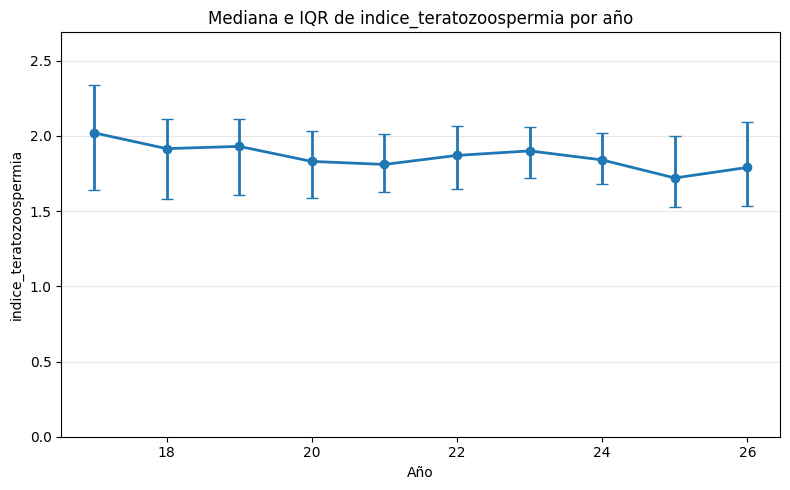

,n,media,mediana,min,max,sd,var,q1,q3,skewness
año,,,,,,,,,,
17,354,1.91,2.02,0.00,2.69,0.61,0.38,1.64,2.34,-1.67
18,398,1.81,1.92,0.00,2.77,0.51,0.26,1.58,2.11,-1.89
19,380,1.77,1.93,0.00,2.96,0.62,0.38,1.60,2.11,-1.79
20,256,1.72,1.83,0.00,2.95,0.56,0.32,1.59,2.03,-1.90
21,303,1.76,1.81,0.00,3.03,0.50,0.25,1.63,2.01,-1.90
22,288,1.75,1.87,0.00,2.72,0.56,0.32,1.65,2.06,-2.02
23,263,1.80,1.90,0.00,2.59,0.48,0.23,1.72,2.06,-2.65
24,256,1.77,1.84,0.00,2.83,0.47,0.22,1.68,2.02,-2.40
25,276,1.68,1.72,0.00,2.63,0.49,0.24,1.53,2.00,-2.09


In [86]:
graficas_numericas('indice_teratozoospermia')

In [87]:
kruskal_var('indice_teratozoospermia')

Kruskal-Wallis
H = 90.3389
p = 0.000000


In [88]:
post_hoc_dunn('indice_teratozoospermia')

,año_1,año_2,p-valor
7,17,25,0.00
3,17,21,0.00
2,17,20,0.00
6,17,24,0.00
22,19,25,0.00
15,18,25,0.00
4,17,22,0.00
40,23,25,0.03
0,17,18,0.03


Parámetros por año teniendo en cuenta días de abstinencia y edad, subclasificación por grupos:

* =< 1, 2, 3, 4, 5, 6, 7 >= dias abstinencia

* < 25, 25-39, 30-34, 35-39, 40-44, 45-49, 50 >= edad

## **Bivariado**

In [89]:
df_sin_texto['grupo_abstinencia'] = pd.cut(
    df_sin_texto['dias_abstinencia'],
    bins=[-np.inf, 1, 2, 3, 4, 5, 6, np.inf],
    labels=['≤1', '2', '3', '4', '5', '6', '≥7']
)

df_sin_texto['grupo_edad'] = pd.cut(
    df_sin_texto['edad'],
    bins=[-np.inf, 24, 29, 34, 39, 44, 49, np.inf],
    labels=['<25', '25-29', '30-34', '35-39', '40-44', '45-49', '≥50']
)

In [90]:
def graficas_edad_abstinencia(var):

    fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)

    # ==========================================================
    # EDAD
    # ==========================================================

    resumen = (
        df_sin_texto
        .groupby(['año', 'grupo_edad'])[var]
        .agg(
            mediana='median',
            q1=lambda x: x.quantile(.25),
            q3=lambda x: x.quantile(.75)
        )
        .reset_index()
    )

    años = sorted(resumen['año'].unique())
    grupos = resumen['grupo_edad'].cat.categories

    x = np.arange(len(años))
    width = 0.10

    for i, grupo in enumerate(grupos):

        datos = (
            resumen[resumen['grupo_edad'] == grupo]
            .set_index('año')
            .reindex(años)
        )

        posicion = x + (i-(len(grupos)-1)/2)*width

        axes[0].errorbar(
            posicion,
            datos['mediana'],
            yerr=[
                datos['mediana']-datos['q1'],
                datos['q3']-datos['mediana']
            ],
            fmt='o',
            capsize=3,
            linewidth=1.5,
            markersize=5,
            label=str(grupo)
        )

    axes[0].set_xticks(x)
    axes[0].set_xticklabels(años)

    axes[0].set_xlabel("Año")
    axes[0].set_ylabel(var)
    axes[0].set_title(f"{var} por grupo etario")

    axes[0].legend(
        title="Edad",
        bbox_to_anchor=(1.02,1),
        loc="upper left"
    )

    axes[0].grid(axis='y', alpha=.3)

    # ==========================================================
    # ABSTINENCIA
    # ==========================================================

    resumen = (
        df_sin_texto
        .groupby(['año', 'grupo_abstinencia'])[var]
        .agg(
            mediana='median',
            q1=lambda x: x.quantile(.25),
            q3=lambda x: x.quantile(.75)
        )
        .reset_index()
    )

    grupos = resumen['grupo_abstinencia'].cat.categories

    for i, grupo in enumerate(grupos):

        datos = (
            resumen[resumen['grupo_abstinencia']==grupo]
            .set_index('año')
            .reindex(años)
        )

        posicion = x + (i-(len(grupos)-1)/2)*width

        axes[1].errorbar(
            posicion,
            datos['mediana'],
            yerr=[
                datos['mediana']-datos['q1'],
                datos['q3']-datos['mediana']
            ],
            fmt='o',
            capsize=3,
            linewidth=1.5,
            markersize=5,
            label=str(grupo)
        )

    axes[1].set_xticks(x)
    axes[1].set_xticklabels(años)

    axes[1].set_xlabel("Año")
    axes[1].set_title(f"{var} por días de abstinencia")

    axes[1].legend(
        title="Abstinencia",
        bbox_to_anchor=(1.02,1),
        loc="upper left"
    )

    axes[1].grid(axis='y', alpha=.3)

    plt.tight_layout()
    plt.show()

### **Bivariado volumen**

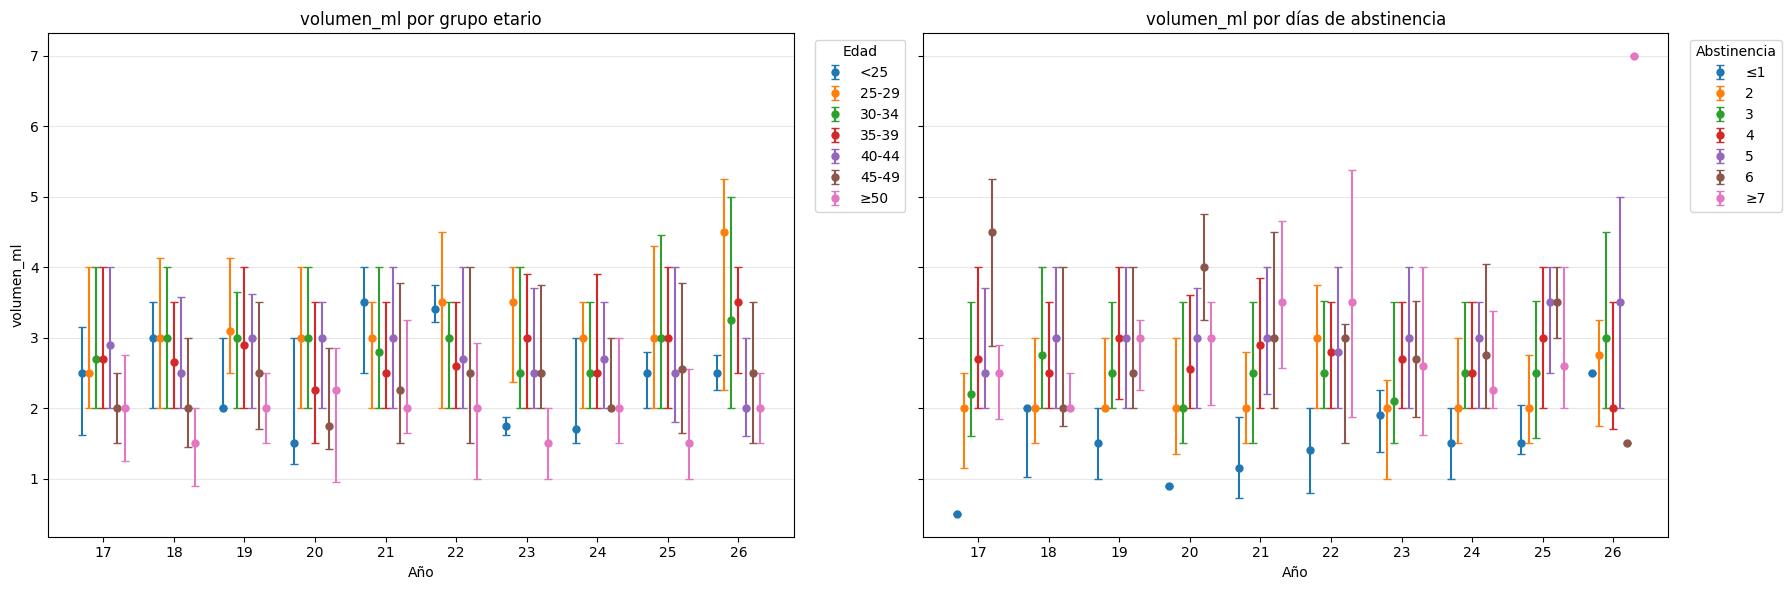

In [91]:
graficas_edad_abstinencia("volumen_ml")

### **Bivariado total eyaculado**

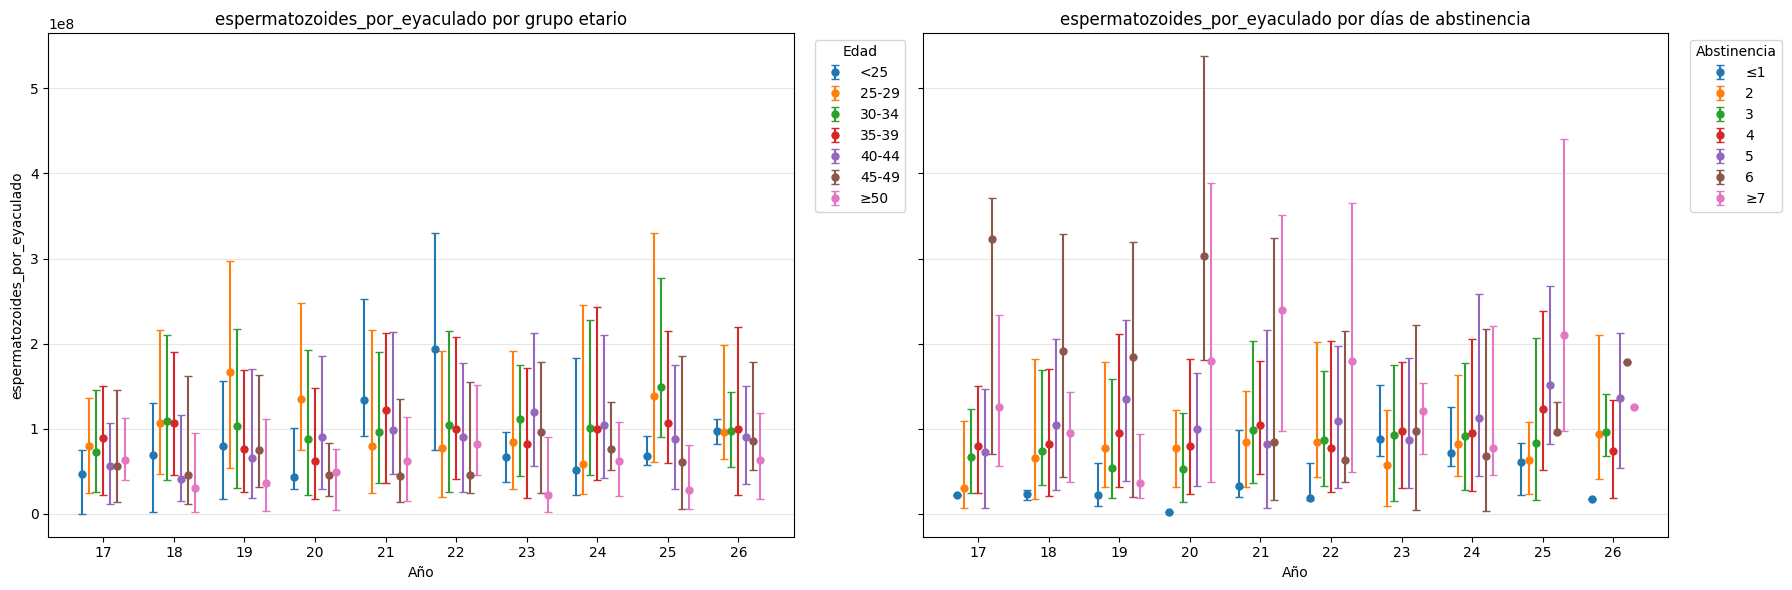

In [92]:
graficas_edad_abstinencia("espermatozoides_por_eyaculado")

### **Bivariado concentración eyaculado**

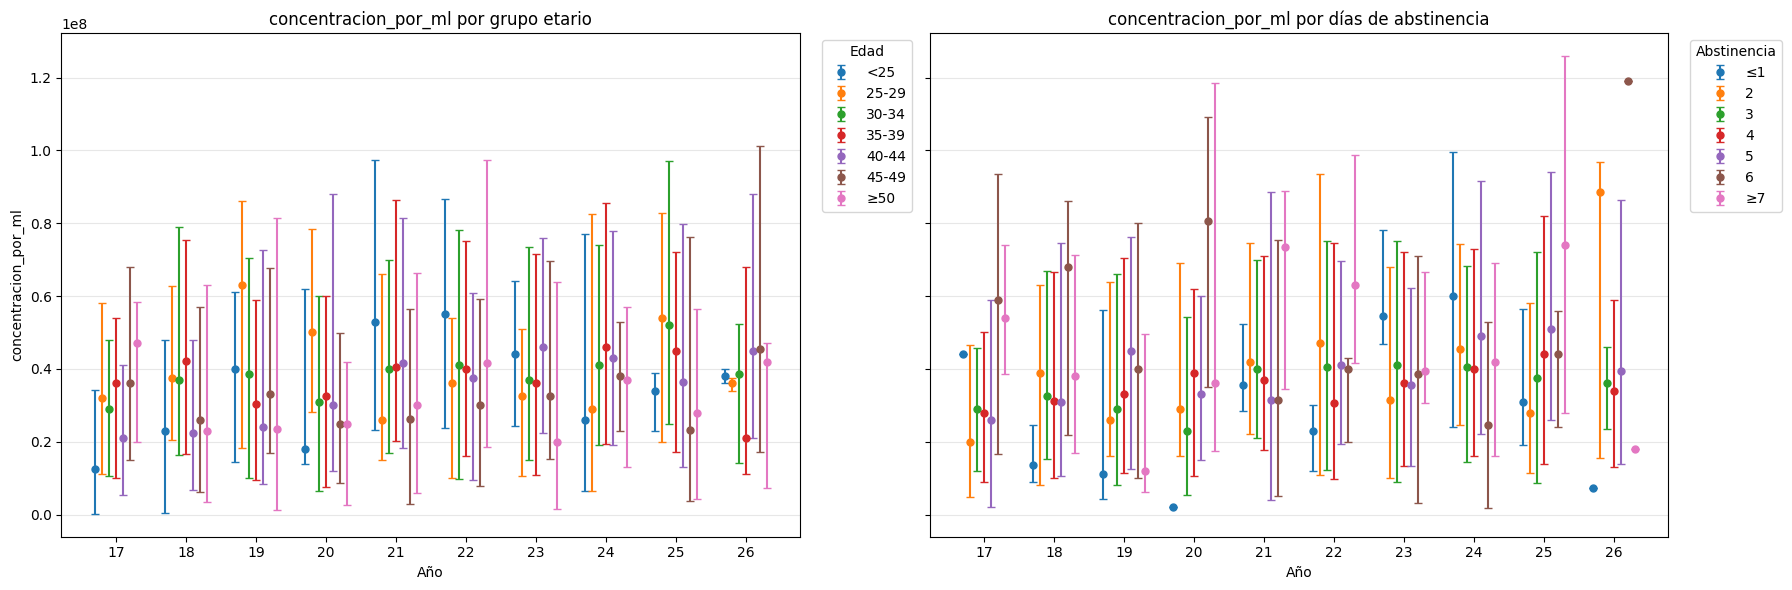

In [93]:
graficas_edad_abstinencia("concentracion_por_ml")

### **Bivariado motilidad progresiva**

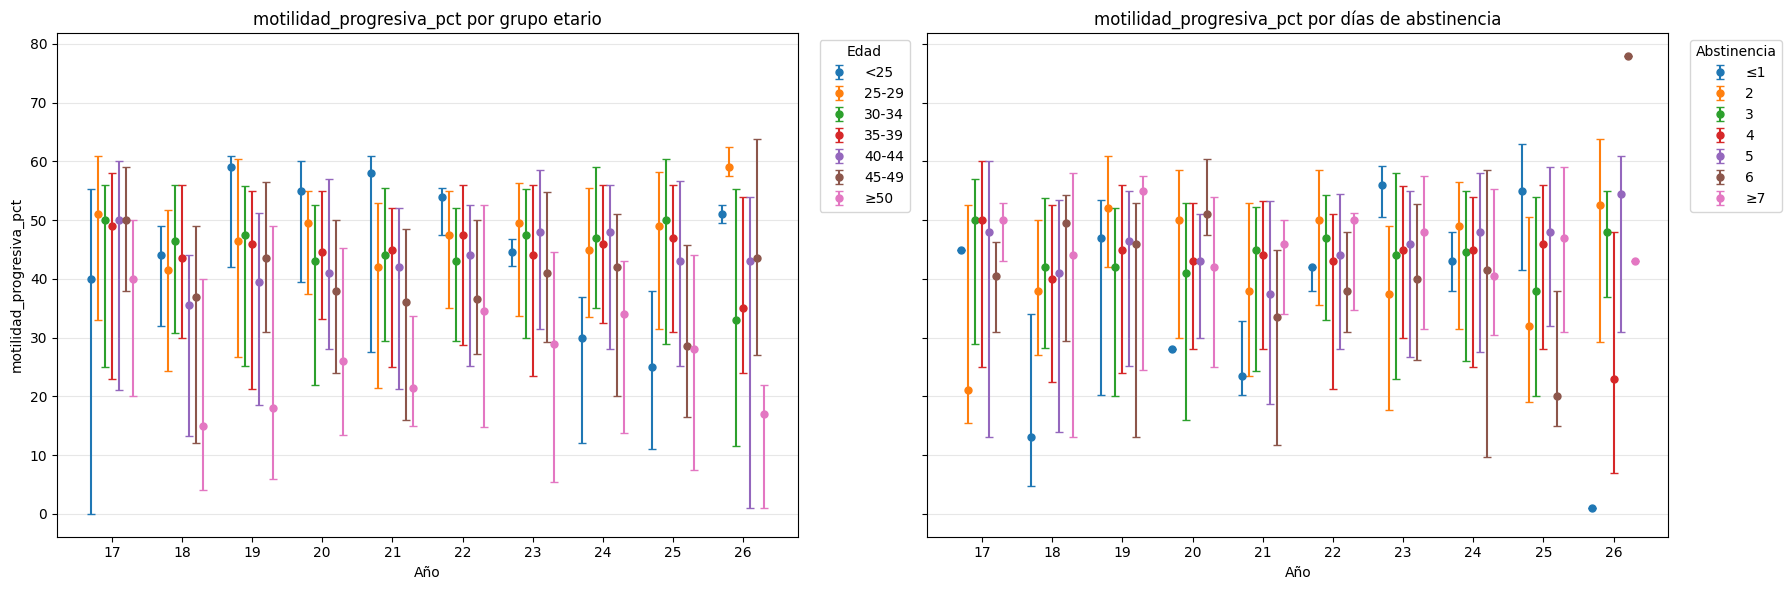

In [94]:
graficas_edad_abstinencia("motilidad_progresiva_pct")

### **Bivariado motilidad total**

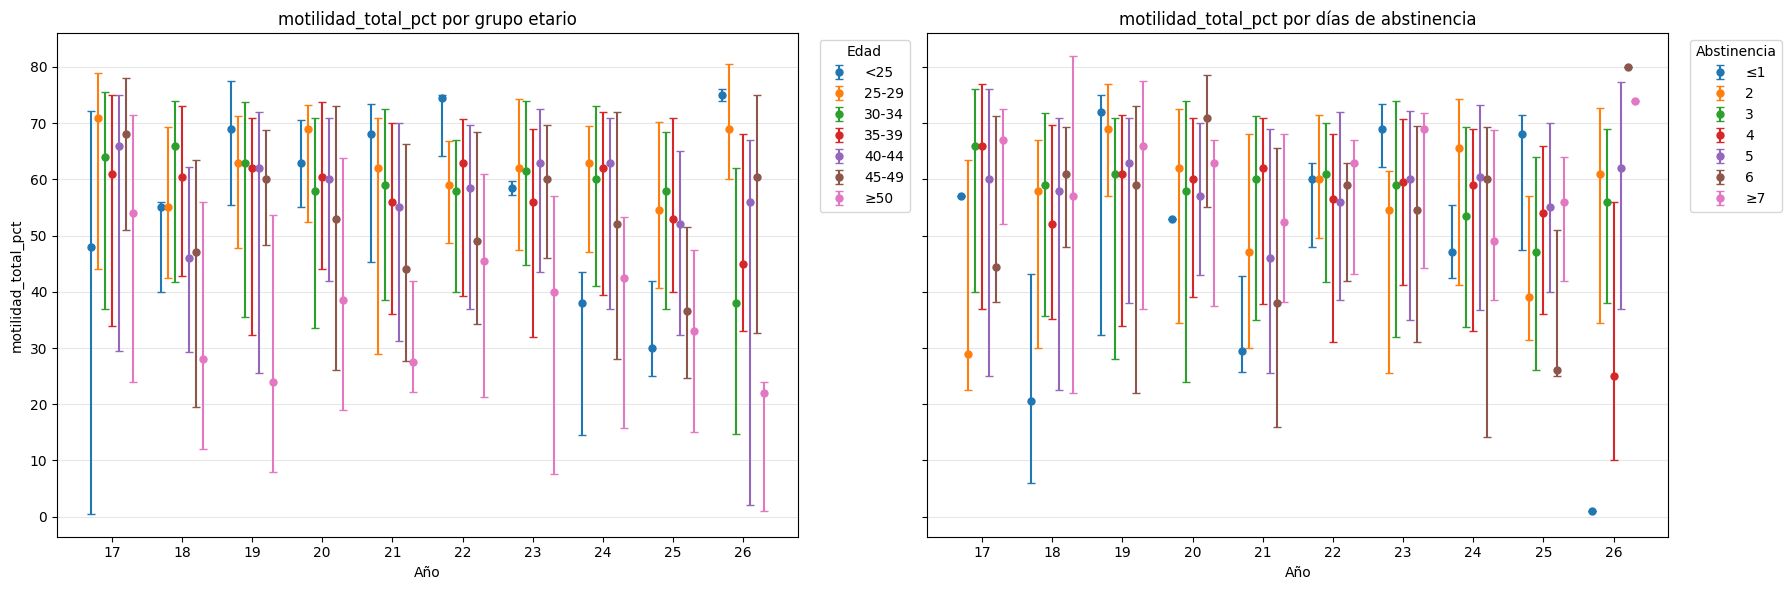

In [95]:
graficas_edad_abstinencia("motilidad_total_pct")

### **Bivariado normales pct**

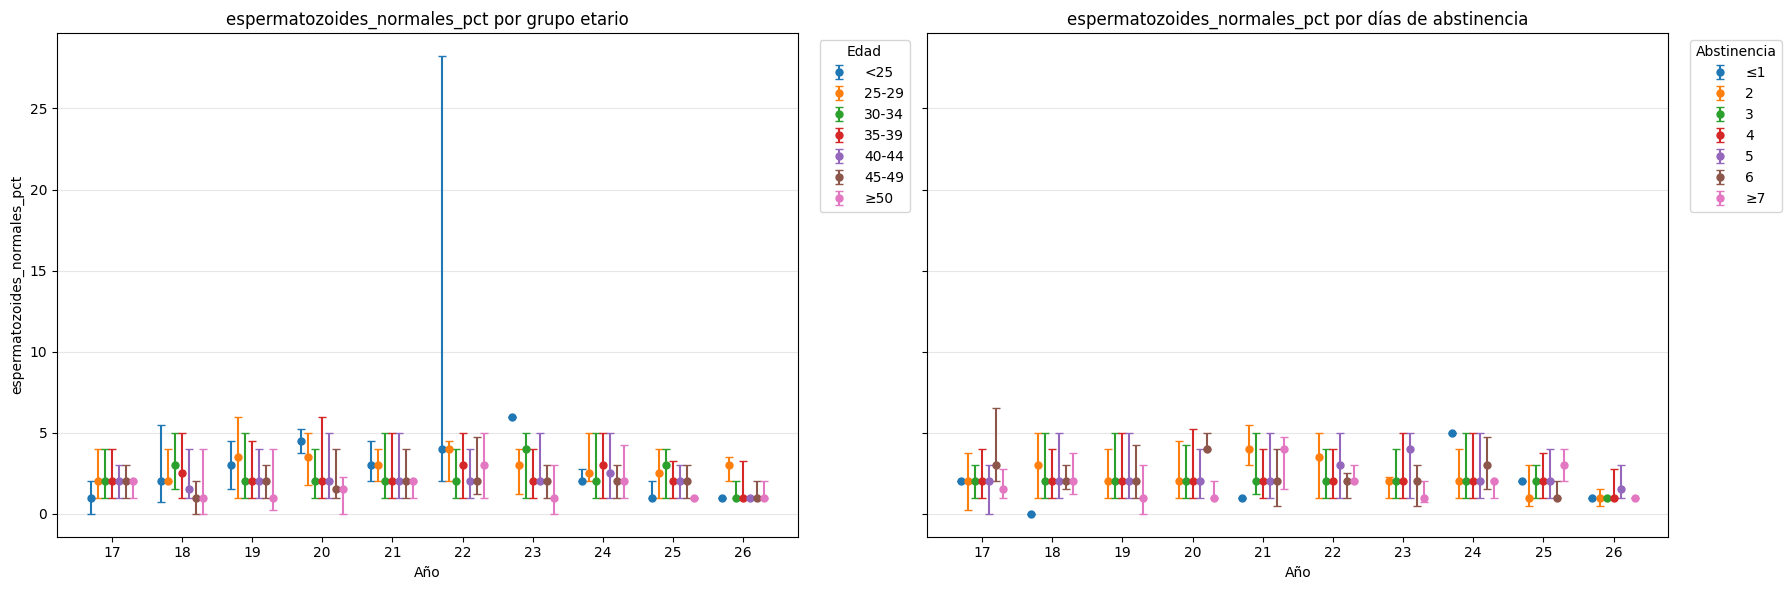

In [96]:
graficas_edad_abstinencia("espermatozoides_normales_pct")

## **Regresiones lineales**

In [97]:
def adjusted_prediction(model, var):
    año_range = np.linspace(df['año'].min(), df['año'].max(), 100)

    X_pred = pd.DataFrame({
        'año': año_range,
        'edad': df['edad'].mean(),
        'dias_abstinencia': df['dias_abstinencia'].mean()
    })

    pred = model.get_prediction(X_pred)
    pred_df = pred.summary_frame(alpha=0.05)

    fig, ax = plt.subplots(figsize=(4, 4))

    ax.fill_between(año_range, pred_df['mean_ci_lower'], pred_df['mean_ci_upper'],
                    color='gray', alpha=0.3, linewidth=0)
    ax.plot(año_range, pred_df['mean'], color='black', linewidth=1)

    ax.set_xlabel('Año')
    ax.set_ylabel(var)

    # Estilo minimalista (quitar bordes superior/derecho)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.show()

### **Volumen**

In [98]:
import statsmodels.formula.api as smf

modelo_vol = smf.ols(
    'volumen_ml ~ año + edad + dias_abstinencia',
    data=df
).fit()

print(modelo_vol.summary())

                            OLS Regression Results                            
Dep. Variable:             volumen_ml   R-squared:                       0.033
Model:                            OLS   Adj. R-squared:                  0.032
Method:                 Least Squares   F-statistic:                     39.73
Date:                Tue, 30 Jun 2026   Prob (F-statistic):           3.10e-25
Time:                        18:26:05   Log-Likelihood:                -6223.3
No. Observations:                3466   AIC:                         1.245e+04
Df Residuals:                    3462   BIC:                         1.248e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            3.6706      0.228  

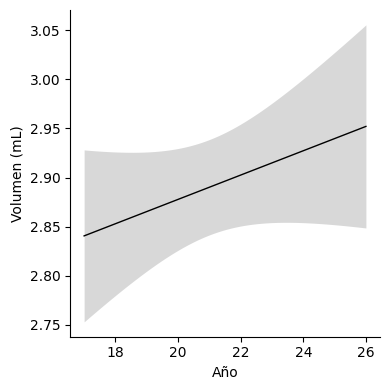

In [99]:
adjusted_prediction(modelo_vol, 'Volumen (mL)')

### **Total eyaculado**

In [100]:
modelo_tot = smf.ols(
    'espermatozoides_por_eyaculado ~ año + edad + dias_abstinencia',
    data=df
).fit()

print(modelo_tot.summary())

                                  OLS Regression Results                                 
Dep. Variable:     espermatozoides_por_eyaculado   R-squared:                       0.032
Model:                                       OLS   Adj. R-squared:                  0.031
Method:                            Least Squares   F-statistic:                     37.56
Date:                           Tue, 30 Jun 2026   Prob (F-statistic):           7.04e-24
Time:                                   18:26:06   Log-Likelihood:                -69764.
No. Observations:                           3467   AIC:                         1.395e+05
Df Residuals:                               3463   BIC:                         1.396e+05
Df Model:                                      3                                         
Covariance Type:                       nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
---------------

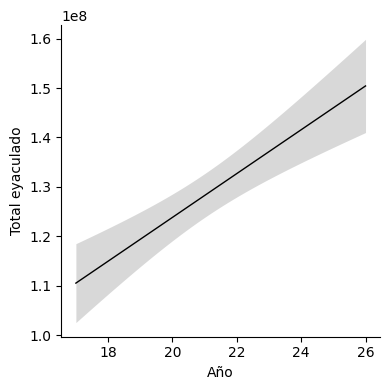

In [101]:
adjusted_prediction(modelo_tot, 'Total eyaculado')

### **Concentración eyaculado**

In [102]:
modelo_conc = smf.ols(
    'concentracion_por_ml ~ año + edad + dias_abstinencia',
    data=df
).fit()

print(modelo_conc.summary())

                             OLS Regression Results                             
Dep. Variable:     concentracion_por_ml   R-squared:                       0.013
Model:                              OLS   Adj. R-squared:                  0.013
Method:                   Least Squares   F-statistic:                     15.71
Date:                  Tue, 30 Jun 2026   Prob (F-statistic):           3.82e-10
Time:                          18:26:06   Log-Likelihood:                -65767.
No. Observations:                  3467   AIC:                         1.315e+05
Df Residuals:                      3463   BIC:                         1.316e+05
Df Model:                             3                                         
Covariance Type:              nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept         2.

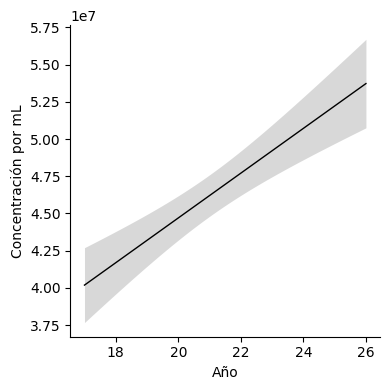

In [103]:
adjusted_prediction(modelo_conc, 'Concentración por mL')

### **Motilidad progresiva**

In [104]:
modelo_mot_prog = smf.ols(
    'motilidad_progresiva_pct ~ año + edad + dias_abstinencia',
    data=df
).fit()

print(modelo_mot_prog.summary())

                               OLS Regression Results                               
Dep. Variable:     motilidad_progresiva_pct   R-squared:                       0.025
Model:                                  OLS   Adj. R-squared:                  0.024
Method:                       Least Squares   F-statistic:                     29.86
Date:                      Tue, 30 Jun 2026   Prob (F-statistic):           4.73e-19
Time:                              18:26:06   Log-Likelihood:                -15317.
No. Observations:                      3465   AIC:                         3.064e+04
Df Residuals:                          3461   BIC:                         3.067e+04
Df Model:                                 3                                         
Covariance Type:                  nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------

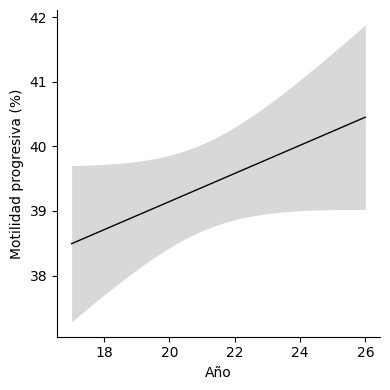

In [105]:
adjusted_prediction(modelo_mot_prog, 'Motilidad progresiva (%)')

### **Motilidad total**

In [106]:
modelo_mot_tot = smf.ols(
    'motilidad_total_pct ~ año + edad + dias_abstinencia',
    data=df
).fit()

print(modelo_mot_tot.summary())

                             OLS Regression Results                            
Dep. Variable:     motilidad_total_pct   R-squared:                       0.026
Model:                             OLS   Adj. R-squared:                  0.025
Method:                  Least Squares   F-statistic:                     30.50
Date:                 Tue, 30 Jun 2026   Prob (F-statistic):           1.86e-19
Time:                         18:26:06   Log-Likelihood:                -15960.
No. Observations:                 3466   AIC:                         3.193e+04
Df Residuals:                     3462   BIC:                         3.195e+04
Df Model:                            3                                         
Covariance Type:             nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           76.3507   

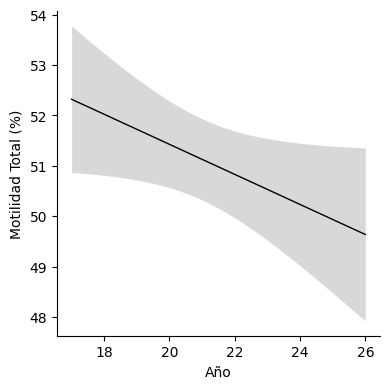

In [107]:
adjusted_prediction(modelo_mot_tot, 'Motilidad Total (%)')

### **Normales pct**

In [108]:
modelo_norm = smf.ols(
    'espermatozoides_normales_pct ~ año + edad + dias_abstinencia',
    data=df
).fit()

print(modelo_norm.summary())

                                 OLS Regression Results                                 
Dep. Variable:     espermatozoides_normales_pct   R-squared:                       0.004
Model:                                      OLS   Adj. R-squared:                  0.003
Method:                           Least Squares   F-statistic:                     4.030
Date:                          Tue, 30 Jun 2026   Prob (F-statistic):            0.00716
Time:                                  18:26:06   Log-Likelihood:                -8255.2
No. Observations:                          2844   AIC:                         1.652e+04
Df Residuals:                              2840   BIC:                         1.654e+04
Df Model:                                     3                                         
Covariance Type:                      nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
-------------------------

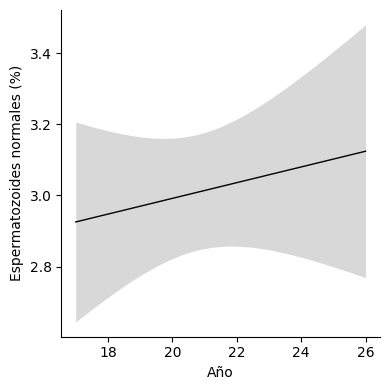

In [109]:
adjusted_prediction(modelo_norm, 'Espermatozoides normales (%)')

## **Análisis intrapaciente**

In [110]:
pacientes = (
    df
    .sort_values(['identificacion','año'])
)

In [111]:
primero = (
    pacientes
    .groupby('identificacion')
    .first()
)

ultimo = (
    pacientes
    .groupby('identificacion')
    .last()
)

In [112]:
pares = (
    primero.add_suffix('_1')
    .join(
        ultimo.add_suffix('_2')
    )
)

pares = pares[pares['codigo_1'] != pares['codigo_2']]

In [113]:
pares['años'] = (
    pares['año_2']-
    pares['año_1']
)


In [114]:
pares['grupo'] = pd.cut(
    pares['años'],
    bins=[-0.1,0,2,5,np.inf],
    labels=[
        '<1 año',
        '1-3 años',
        '3-5 años',
        '>5 años'
    ]
)

In [115]:
pares['grupo'].value_counts()

grupo
1-3 años    186
<1 año      184
3-5 años     73
>5 años      16
Name: count, dtype: int64

### **Volumen**

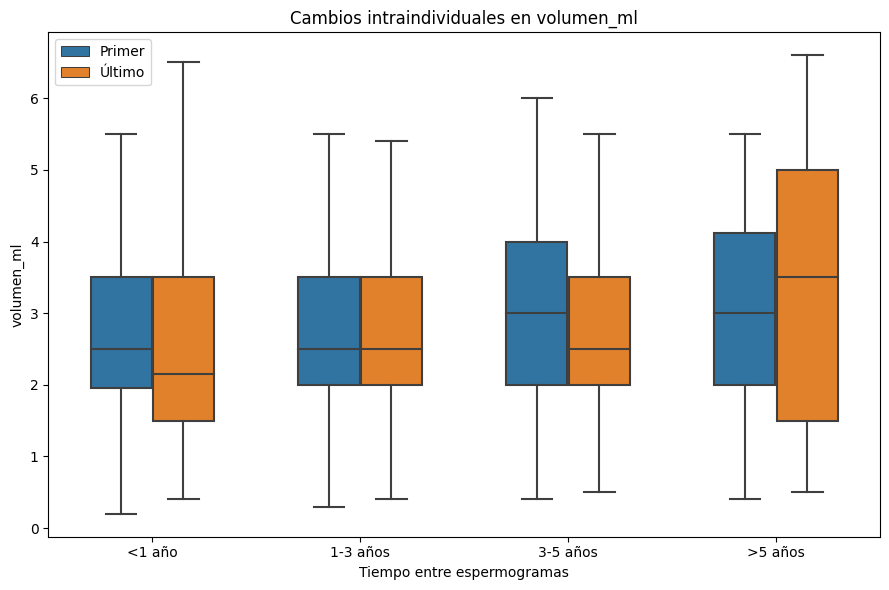

In [119]:
def grupos_intra(variable):
    plot_df = pd.concat([
        pares[['grupo', f'{variable}_1']].rename(
            columns={f'{variable}_1': variable}
        ).assign(Muestra='Primer'),

        pares[['grupo', f'{variable}_2']].rename(
            columns={f'{variable}_2': variable}
        ).assign(Muestra='Último')
    ])

    plt.figure(figsize=(9,6))

    sns.boxplot(
        data=plot_df,
        x='grupo',
        y=variable,
        hue='Muestra',
        width=0.6,
        showfliers=False
    )

    plt.xlabel("Tiempo entre espermogramas")
    plt.ylabel(variable)
    plt.title(f"Cambios intraindividuales en {variable}")

    plt.legend(title="")
    plt.tight_layout()
    plt.show()

grupos_intra('volumen_ml')

### **Total eyaculado**

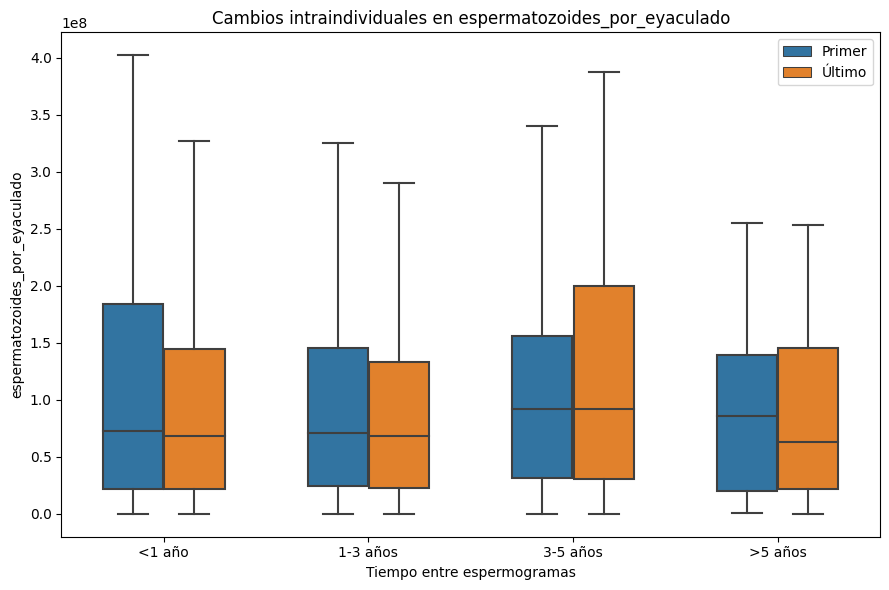

In [120]:
grupos_intra('espermatozoides_por_eyaculado')

### **Concentración eyaculado**

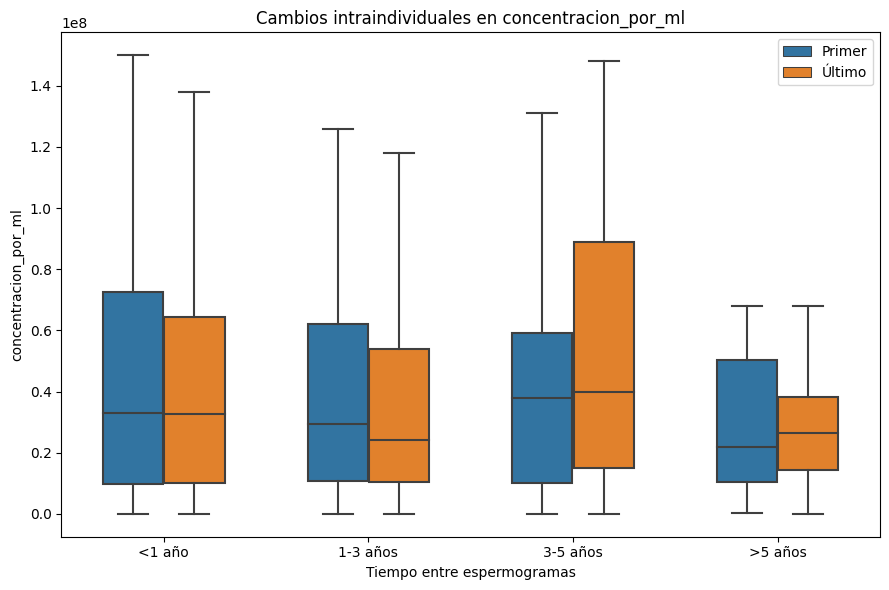

In [121]:
grupos_intra('concentracion_por_ml')

### **Motilidad progresiva**

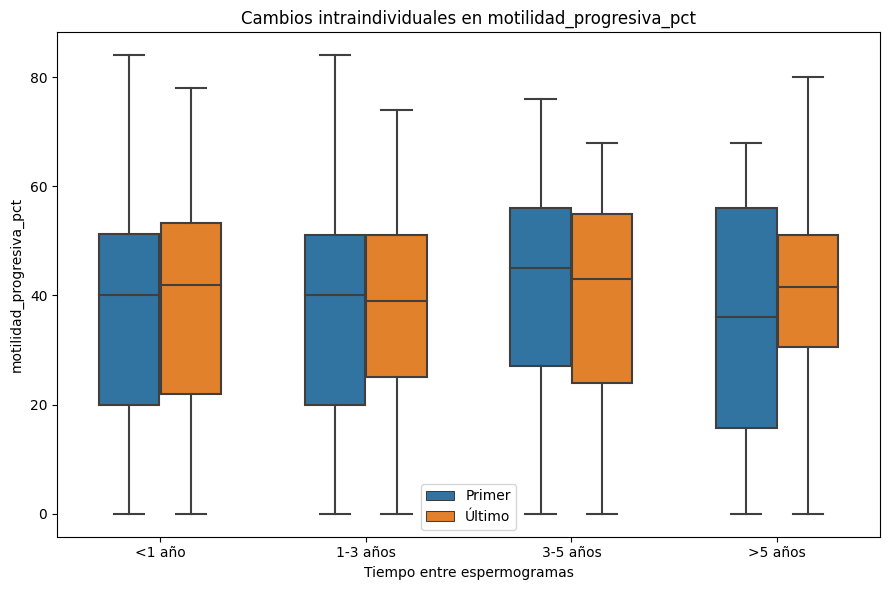

In [122]:
grupos_intra('motilidad_progresiva_pct')

### **Motilidad total**

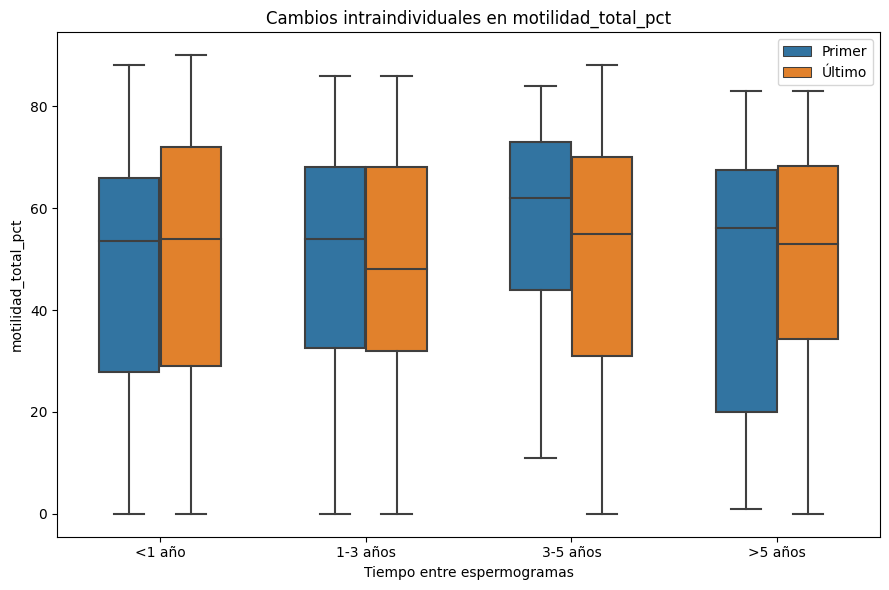

In [123]:
grupos_intra('motilidad_total_pct')

### **Normales pct**

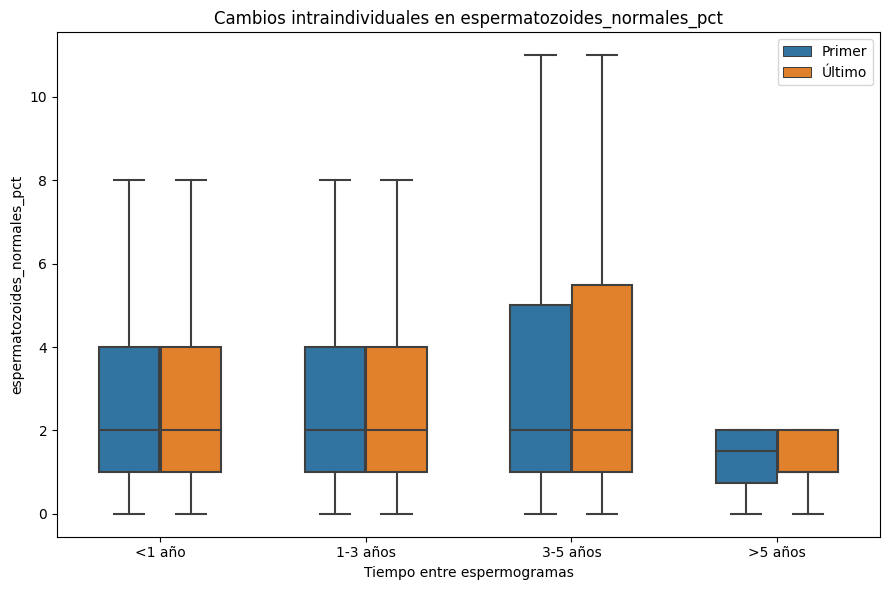

In [124]:
grupos_intra('espermatozoides_normales_pct')